# Ensemble Kaggle branch

In this notebook we process te image input and train an ensemble model with 
different arquitectures

In [1]:
print("Santi eres muy bueno")

Santi eres muy bueno


In [2]:
# --- Imports & config ---
from pathlib import Path
import numpy as np
import pandas as pd
import torch.nn as nn
import timm
import os
import random
import joblib
from sklearn.model_selection import StratifiedGroupKFold
import time, torch
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
import cv2
import albumentations as A
import lightgbm as lgb

import sys
sys.path.insert(0, r"C:\Users\alexs\Downloads\ISIC_DL-santi\ISIC_DL-santi\utils2")
import importlib.util
spec = importlib.util.spec_from_file_location("utils_custom", r"C:\Users\alexs\Downloads\ISIC_DL-santi\ISIC_DL-santi\utils2\utils.py")
utils_custom = importlib.util.module_from_spec(spec)
sys.modules['utils_custom'] = utils_custom
spec.loader.exec_module(utils_custom)

from utils_custom import (create_balanced_split, 
                   ISIC_Multimodal_Dataset, 
                   get_best_metadata, 
                   MetadataProcessor,
                   AdvancedHairAugmentation, 
                   Microscope,
                   get_fold_datalodaers,
                   TrainableModule, 
                   remove_last_layer,   
                   plot_analisis,
                   plot_stats)

# configure all:
class config:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data_dir = Path("../data")
    models_dir = Path("../models")
    utils_dir = Path("../utils2")
    submission_dir = Path("../submission")
    train_meta_csv = data_dir / "train-metadata.csv"
    test_meta_csv = data_dir / "test-metadata.csv"
    train_hdf5 = data_dir / "train-image.hdf5"
    test_hdf5 = data_dir / "test-image.hdf5"
    meta_procesor = utils_dir / "metadata_processor.pkl"
    metamodel_path = utils_dir / "metamodel.plk"
    ensemble_train_csv = utils_dir / "ensemble_train.csv"
    hairs_path = utils_dir / "hairs"
    lr = 1e5
    mean = [0.485, 0.456, 0.406],
    std = [0.229, 0.224, 0.225],
    seed = 42
    image_size = 224
    epochs = 50
    batch_size = 16
    num_imgs_epoch = 3000
    target_epoch_proportion = 0.50
    BCE_loss_pos_weight = 1
    ratio_neg_pos = 25
    val_split = 0.2             # of train
    num_folds = 5
    num_feat = 0                # 0 = use all
    fine_tuning_batch = 10      # batch to train ensemble models
    val_freq = 5                # frequency of validation analisis
    attention_dim = 256         # dimension of trained attention ensemble
    unfreeze_schedule = [
        (5, 0.2),   # in epoch 5, 20%
        (40, 0.5),  # in epoch 30, 50%
        # (65, 0.75), # in epoch 65, 75%
    ]

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

seed_everything(config.seed)

## Load and analyze the data

Because of the extreme class imbalance in the ISIC dataset (≈0.01% malignant vs. 99.99% benign), we apply two complementary strategies.  
First, we limit the number of benign samples by enforcing a controlled ratio of **25 benign lesions per malignant lesion** during training.  
Second, we apply an extensive yet medically appropriate **augmentation pipeline** to increase the effective diversity of malignant samples and reduce overfitting.

Below is a summary of the augmentation strategy used.

---

## Data Augmentation for Skin Lesion Classification (ISIC)

To improve the robustness of our multimodal classifier, we apply a set of **recommended and dermatology-consistent augmentations**, inspired by prior work on dermoscopic augmentation. In particular, our use of `AdvancedHairAugmentation` and `Microscope` artifacts was borrowed from the approach of GreatGameDota/SIIM-ISIC-Melanoma-Classification. :contentReference[oaicite:2]{index=2}

These transformations simulate realistic sources of variability such as camera angle, zoom, lighting, dermoscopic artifacts, and partial occlusions.

### 🔧 Summary of the Training Augmentation Pipeline

1. **Geometric Transformations (OneOf: ShiftScaleRotate / Affine / Perspective)**  
   A single transformation is chosen at random:
   - **ShiftScaleRotate**: small shifts, scaling (±15%), and rotations (±80°).  
   - **Affine (shear)**: simulates slight camera tilt.  
   - **Perspective**: mimics viewpoint variation.  
   **Purpose:** models acquisition differences across dermatoscopes while preserving lesion morphology.

2. **Horizontal & Vertical Flip (p=0.5 each)**  
   **Purpose:** lesions have no fixed orientation; flipping increases spatial variability safely.

3. **Resize to fixed resolution**  
   Ensures all images match the model input size.

4. **AdvancedHairAugmentation (p=0.5)** — *inspired by* GreatGameDota/SIIM-ISIC solution  
   Adds realistic synthetic hairs over the image.  
   **Purpose:** increases robustness to one of the most common dermoscopic artifacts (hairs).

5. **RandomBrightnessContrast**  
   **Purpose:** simulates differences in lighting conditions, camera exposure, and skin tone variability.

6. **CoarseDropout (1–8 holes, up to 25% area)**  
   Randomly removes patches of the image.  
   **Purpose:** simulates partial occlusions (e.g. ruler marks, bubbles, ink, gel, hair clusters) and improves robustness.

7. **Microscope Effect (p=0.1)** — *inspired by* GreatGameDota/SIIM-ISIC solution  
   Adds subtle lens or artefact-like distortions to simulate variability across dermatoscopic devices.  
   **Purpose:** increases generalization frente a variaciones de dispositivo o iluminación.

8. **Normalize (mean=0, std=1)**  
   Standard normalization for stable training.

### Validation Transformations

- **Resize** to input size  
- **Normalize** (mean=0, std=1)  

No augmentation is applied at validation time in order to evaluate performance on unaltered data.

---

## Scientific Support

These transformations are compatible with recommended augmentation practices in biomedical imaging. In particular, hair-artifact simulation and occlusion–robust augmentation han sido utilizados con éxito en pipelines para clasificación de melanoma (ver GreatGameDota/SIIM-ISIC-Melanoma-Classification).  
Además, trabajos como Towards Better Dermoscopic Image Feature Representation Learning for Melanoma Classification destacan que la presencia de artefactos (pelo, marcas, iluminación variable) representa un reto real en imágenes dermatoscópicas, y que estrategias como augmentación con oclusiones o ruido son útiles para mejorar la generalización. :contentReference[oaicite:4]{index=4}

---

Together, this augmentation pipeline improves generalization, reduces overfitting, and compensates for the scarcity of malignant samples in the dataset.


In [3]:
train_transform = A.Compose([
    A.OneOf([
        A.ShiftScaleRotate(scale_limit=0.15, rotate_limit=80, shift_limit=0.1,
                           border_mode=cv2.BORDER_REPLICATE, p=0.5),
        A.Affine(shear=20, p=0.5),  # 'mode' eliminado
        A.Perspective(p=0.5),
    ], p=0.5),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Resize(config.image_size, config.image_size),

    AdvancedHairAugmentation(hairs=10, hairs_folder=config.hairs_path, p=0.5),
    A.RandomBrightnessContrast(),

    # CoarseDropout nuevo: usa num_holes, max_height, max_width
    A.CoarseDropout(num_holes_range=(1, 8),
                    hole_height_range=(0.1, 0.25),
                    hole_width_range=(0.1, 0.25), 
                    fill=0, p=0.3),
    Microscope(p=0.1),

    # Normalize nuevo: no usar always_apply
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0))
])

val_transform = A.Compose([
    A.Resize(config.image_size, config.image_size),
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0))
])

C:\Users\alexs\AppData\Roaming\Python\Python310\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\alexs\Downloads\ISIC_DL-santi\ISIC_DL-santi\utils2\utils.py:436: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)


## Dataset analisis

In [4]:
# 1º Create a split of train and validation balanced
# we dont need all the images
train_df, val_df, df_balanced = create_balanced_split(
    config.train_meta_csv,
    neg_multiplier=config.ratio_neg_pos,      # conservative ratio of 25:1 
    val_frac=config.val_split            # split a 20% of train to validation
)

test_df = pd.read_csv(config.test_meta_csv, low_memory=False)

# 2º Run the metadata processor
# Always recreate to avoid pickle import issues
print("Creating metadata processor...")
best_features = get_best_metadata(train_df, test_df, num_feat=config.num_feat, verbose=True)
metadata_processor = MetadataProcessor(best_features)
metadata_processor.fit(pd.read_csv(config.train_meta_csv))
print("✓ Metadata processor created")

train_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=config.train_hdf5,
    metadata_df=train_df,
    image_transform=train_transform,
    metadata_processor=metadata_processor
)

val_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=config.train_hdf5,
    metadata_df=val_df,
    image_transform=val_transform,
    metadata_processor=metadata_processor
)

test_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=config.test_hdf5,
    metadata_df=test_df,
    image_transform=val_transform,
    metadata_processor=metadata_processor
)

C:\Users\alexs\Downloads\ISIC_DL-santi\ISIC_DL-santi\utils2\utils.py:143: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(metadataCSV_path)


Positives: 343
Negatives available: 400616
Negatives to sample: 8575

Balanced dataset size: 8918
target
0    8575
1     343
Name: count, dtype: int64
Creating metadata processor...

✔ Using all metadata features


C:\Users\alexs\AppData\Local\Temp\ipykernel_6496\2990574565.py:16: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_processor.fit(pd.read_csv(config.train_meta_csv))


✓ Metadata processor created


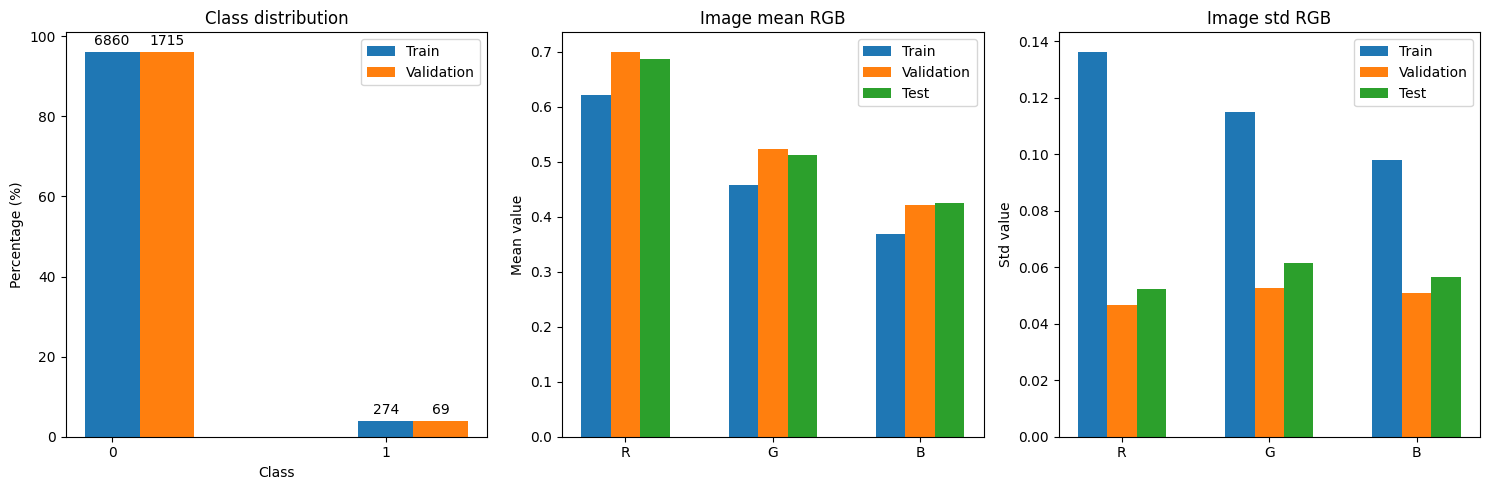

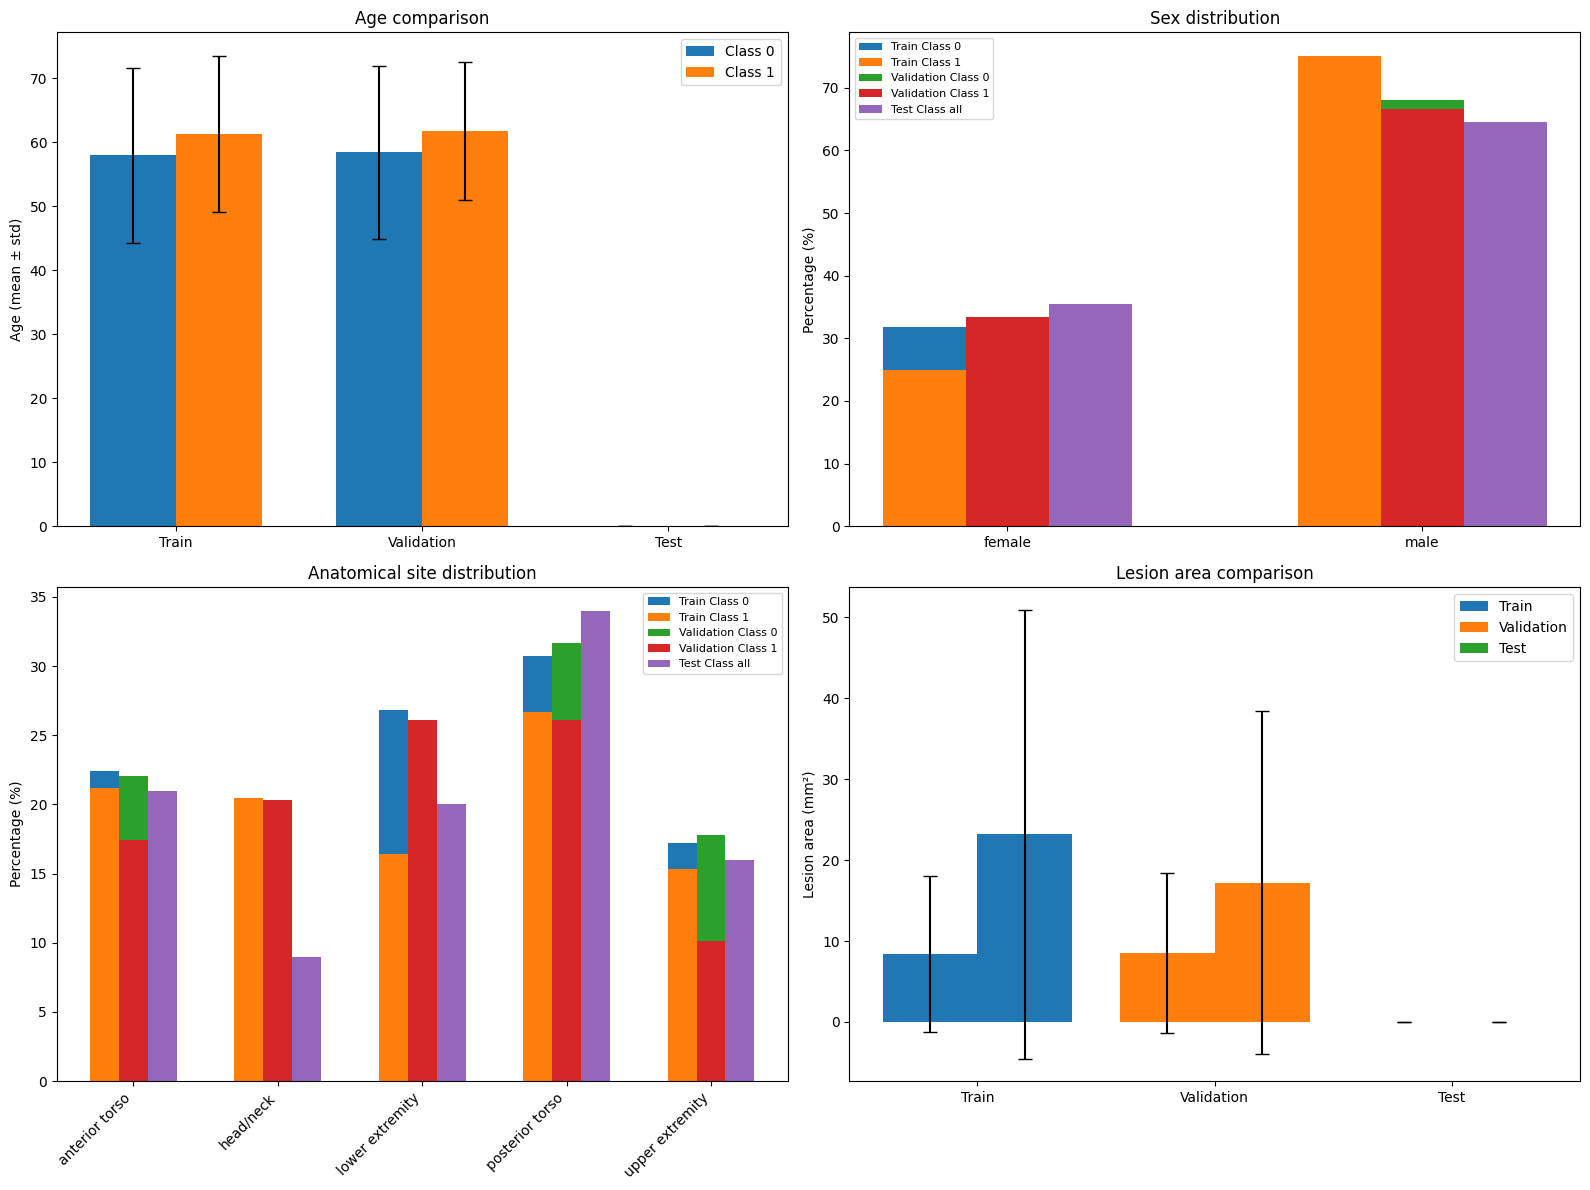

In [5]:
train_stats = train_dataset.get_dataset_stats(sample_size=300)
val_stats   = val_dataset.get_dataset_stats(sample_size=300)
test_stats  = test_dataset.get_dataset_stats(sample_size=300)
stats_list = [train_stats, val_stats, test_stats]

# clean dataset variables
train_dataset = None
val_dataset = None

# Now we compare the analisis of the splits
plot_stats(stats_list)

## DataLoaders with KFolds and Weighted sampler

We calculate the **ratio of the weighted sampler** using the formula:
$$
w_{c1}=\frac{p_{target}}{1-p_{target}}\frac{n_{c1}}{n_{c2}}
$$
so in the example we want $ p_{target} = 0.25 $
$$
w_{c1}=\frac{0.25}{0.75}\frac{20}{1}
$$

For the weights of the loss functions is as follows:
$$
pos_w=\frac{1-p_{posImg}}{p_{posImg}}
$$

In [6]:
kfold = StratifiedGroupKFold(
    n_splits=config.num_folds,
    shuffle=True,
    random_state=config.seed
)

# loaders 
traink_df = []
valk_df = []

fold_stats = []

for k, (train_idx, val_idx) in enumerate(
    kfold.split(train_df, train_df["target"], train_df["patient_id"])):

    train_spl = train_df.iloc[train_idx]
    val_spl = train_df.iloc[val_idx]

    train_counts = train_spl["target"].value_counts().reindex([0,1], fill_value=0)
    val_counts   = val_spl["target"].value_counts().reindex([0,1], fill_value=0)

    fold_stats.append({
        "fold": k,
        "train_total": len(train_spl),
        "tr_class_0": train_counts[0],
        "tr_class_1": train_counts[1],
        "tr_class1_%": train_counts[1] / len(train_spl),

        "val_total": len(val_spl),
        "val_class_0": val_counts[0],
        "val_class_1": val_counts[1],
        "val_class1_%": val_counts[1] / len(val_spl),
    })

    traink_df.append(train_spl)
    valk_df.append(val_spl)

# we only need test loader for kaggle submission
test_loader = DataLoader(
    test_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True if config.device == 'cuda' else False
)

print("📦 Multimodal data loaders created with balanced sampling!")
fold_stats_df = pd.DataFrame(fold_stats)

print("\n📊 Distribution for each fold:\n")
print(fold_stats_df.to_string(index=False))


📦 Multimodal data loaders created with balanced sampling!

📊 Distribution for each fold:

 fold  train_total  tr_class_0  tr_class_1  tr_class1_%  val_total  val_class_0  val_class_1  val_class1_%
    0         5697        5471         226     0.039670       1437         1389           48      0.033403
    1         5702        5474         228     0.039986       1432         1386           46      0.032123
    2         5837        5625         212     0.036320       1297         1235           62      0.047803
    3         5664        5447         217     0.038312       1470         1413           57      0.038776
    4         5636        5423         213     0.037793       1498         1437           61      0.040721


# Backbone

In [7]:
class AttentionFusion(nn.Module):
    """
    Fusiona img_emb y meta_emb usando Multi-Head Attention real.
    Produce una predicción escalar (1 dimensión).
    """
    def __init__(self, dim, num_heads=4, num_classes=1):
        super().__init__()

        # Multi-Head Attention (Transformer) para fusionar ambos tokens
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, batch_first=False)

        # Proyección del token fusionado
        self.fusion_proj = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(dim // 2, dim // 4),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        # Predicción escalar final
        self.out = nn.Linear(dim // 4, num_classes)

    def forward(self, img_emb, meta_emb):
        """
        img_emb:  (batch, dim)
        meta_emb: (batch, dim)
        returns: (batch, 1)
        """

        # Construimos tokens → secuencia de longitud 2
        tokens = torch.stack([img_emb, meta_emb], dim=0)  
        # tokens shape: (2, batch, dim)

        # Self-attention sobre los dos tokens
        attn_out, _ = self.attn(tokens, tokens, tokens)
        # attn_out shape: (2, batch, dim)

        # Fusion: agregamos ambos tokens
        fused = attn_out.mean(dim=0)  # (batch, dim)

        # Pasamos por MLP
        fused = self.fusion_proj(fused)

        # Predicción escalar
        pred = self.out(fused)

        return pred
    
class EmbeddingHead(nn.Module):
    def __init__(self, input_dim, emb_dim):
        super().__init__()
        self.net = nn.Sequential(
        nn.Flatten(),
        nn.Dropout(0.4),
        nn.Linear(input_dim, emb_dim),
        nn.BatchNorm1d(emb_dim),
        nn.GELU()
        )
    
    def forward(self, x):
        return self.net(x)

class MetaEncoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim=1024):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.8),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.BatchNorm1d(hidden_dim//2),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim//2, emb_dim)
        )
    def forward(self, x):
        return self.net(x)

class PretrainedClassifier(nn.Module):
    def __init__(self, device, model_name, model_origin, meta_dim,
                 num_classes=1, hidden_dim = 512):
        super().__init__()

        self.hidden_dim = hidden_dim

        # ----- Backbone for the image ------
        if model_origin == ".pt":
            self.backbone = torch.load(model_name)
            # change last layer
            self.backbone = remove_last_layer(self.backbone)

        elif model_origin == "timm":
            self.backbone = timm.create_model(
                model_name,
                pretrained=True,
                global_pool='avg',
                num_classes=0  # don't use the original detection head
            )

        # add a trainable head to the backbone
        self.backbone.to(device)
        self.device = device
        with torch.no_grad():
            dummy_img = torch.zeros(1, 3, 224, 224).to(device)
            img_feat = self.backbone(dummy_img)
        self.img_dim = img_feat.shape[1]

        # freeze the backbone
        for p in self.backbone.parameters():
            p.requires_grad = False

        self.backbone_head = EmbeddingHead(self.img_dim, 
                                          self.hidden_dim//2).to(device)
        
        # ------ Metadata Model -------
        self.metadata_encoder = MetaEncoder(meta_dim, emb_dim=self.hidden_dim//2).to(device)

        # ------ Fusion with attention ------
        self.attention_fusion = AttentionFusion(dim=self.hidden_dim//2, 
                                                num_heads=4,
                                                num_classes=num_classes
                                                ).to(device)


    def forward(self, images, metadata):
        # ---- Image embedding ----
        backbone_img = self.backbone(images)
        img_emb = self.backbone_head(backbone_img)

        # ---- Metadata embedding ---
        meta_emb = self.metadata_encoder(metadata)

        #----- Attention fusion -----
        out = self.attention_fusion(img_emb, meta_emb)
        return out

class PretrainedClassifierExtended(PretrainedClassifier, TrainableModule):
    def __init__(self, device, model_name, model_origin, unfreeze_scheduler, meta_dim,
                 lr, criterion, val_freq=5, patience=5, min_delta=0.01):
        PretrainedClassifier.__init__(self, device, model_name, model_origin, meta_dim)
        TrainableModule.__init__(self, criterion, device, patience, min_delta)

        self.name = model_name
        self.unfreeze_schedule = unfreeze_scheduler
        self.model_origin = model_origin
        self.val_freq = val_freq    # freq of validation metrics
        self.lr=lr
        self.history = {
            "train_loss": [],
            "val_loss": [],
            "val_auc": []
        }

    def fit(self, train_loader, val_loader=None, epochs=10):
        print(f"----------------------------------------")
        print(f"       Training {self.name}")
        print(f"----------------------------------------")

        for epoch in range(1, epochs+1):
            torch.cuda.empty_cache()
            start = time.time()
            print(f"Epoch {epoch}/{epochs}: ", end="")

            for e, pct in self.unfreeze_schedule:
                if epoch == e:
                    self.unfreeze_backbone_layers(pct)
                    print(f"Descongelando {pct*100:.0f}% del backbone en epoch {epoch}")

            train_loss, per_pos = self._train_epoch(train_loader)
            self.history["train_loss"].append(train_loss)
            print(f"Train loss: {train_loss:.4f} || percentaje pos in epoch: {per_pos:.3f}%")

            if val_loader and epoch%self.val_freq==0:
                val_loss, val_auc = self._validate(val_loader)
                self.history["val_loss"].append(val_loss)
                self.history["val_auc"].append(val_auc)
                print(f"Val Loss: {val_loss:.4f} | AUC: {val_auc:.4f}", end="")
            
            # 🧹 Clean epoch for VRAM
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

            
            print(f" in {time.time() - start:.2f}s")

    def unfreeze_backbone_layers(self, percent=0.2):
        layers = list(self.backbone.parameters())
        n_total = len(layers)
        n_unfreeze = int(n_total * percent)

        # unfreeze the last layers
        for p in layers[-n_unfreeze:]:
            p.requires_grad = True
    
    def load(self, path):
        state = torch.load(path, map_location=self.device, weights_only=True)
        self.load_state_dict(state)
        self.to(self.device)

### Train the mix models

📂 efficientnet_b0_f0 loaded from memory


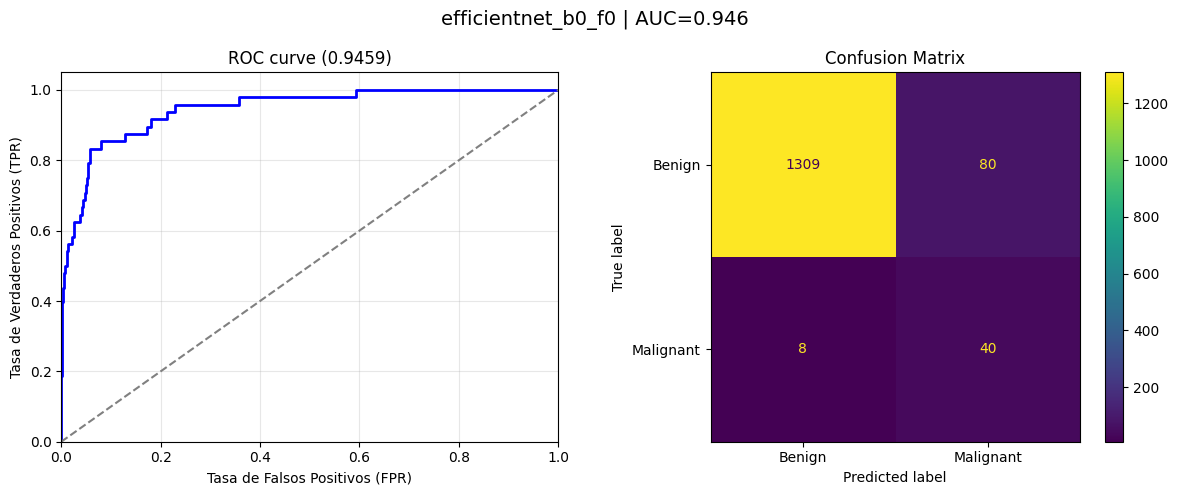

Inference on Test: 100%|██████████| 7/7 [00:01<00:00,  5.48it/s]


Saved submission with 100 rows to ../submission/efficientnet_b0.csv
📂 efficientnet_b0_f1 loaded from memory


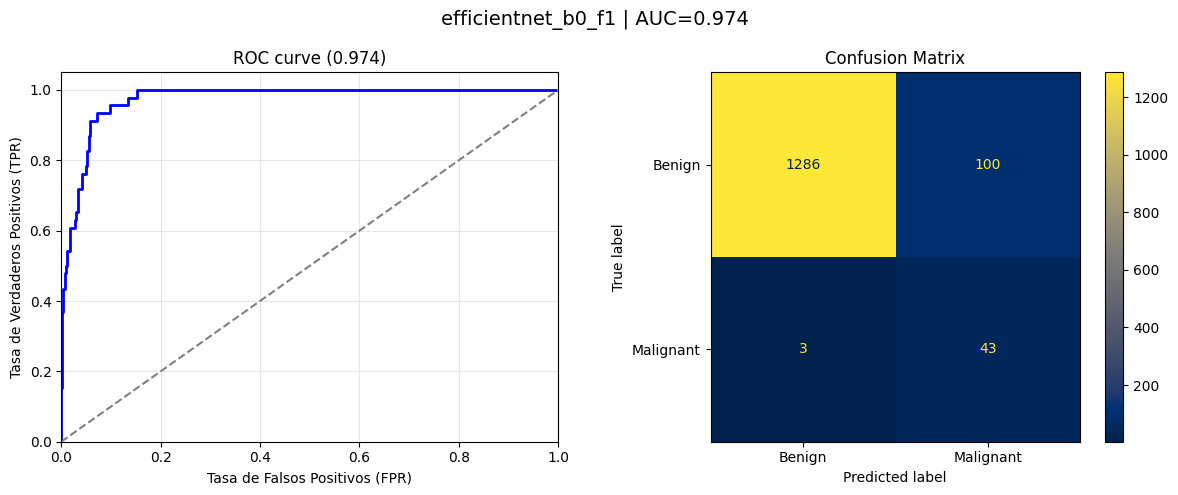

Inference on Test: 100%|██████████| 7/7 [00:00<00:00,  9.40it/s]


Saved submission with 100 rows to ../submission/efficientnet_b0.csv
📂 efficientnet_b0_f2 loaded from memory


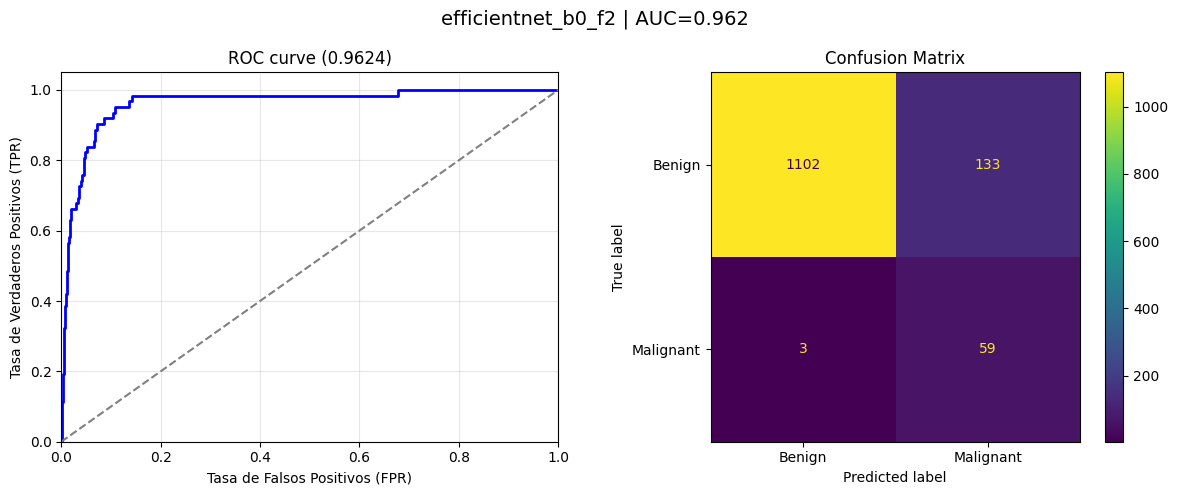

Inference on Test: 100%|██████████| 7/7 [00:00<00:00, 10.38it/s]


Saved submission with 100 rows to ../submission/efficientnet_b0.csv
📂 efficientnet_b0_f3 loaded from memory


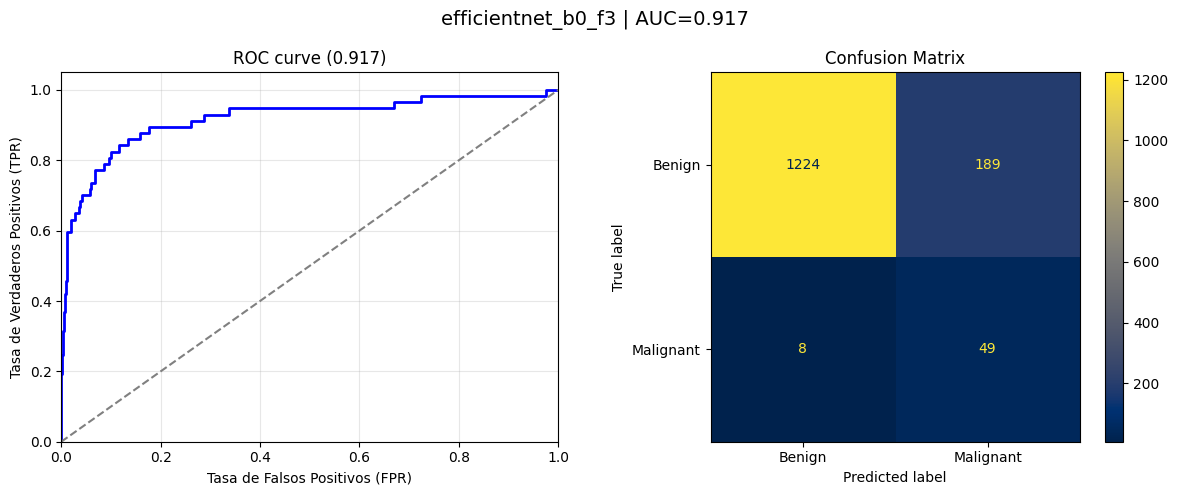

Inference on Test: 100%|██████████| 7/7 [00:00<00:00, 11.05it/s]


Saved submission with 100 rows to ../submission/efficientnet_b0.csv
📂 efficientnet_b0_f4 loaded from memory


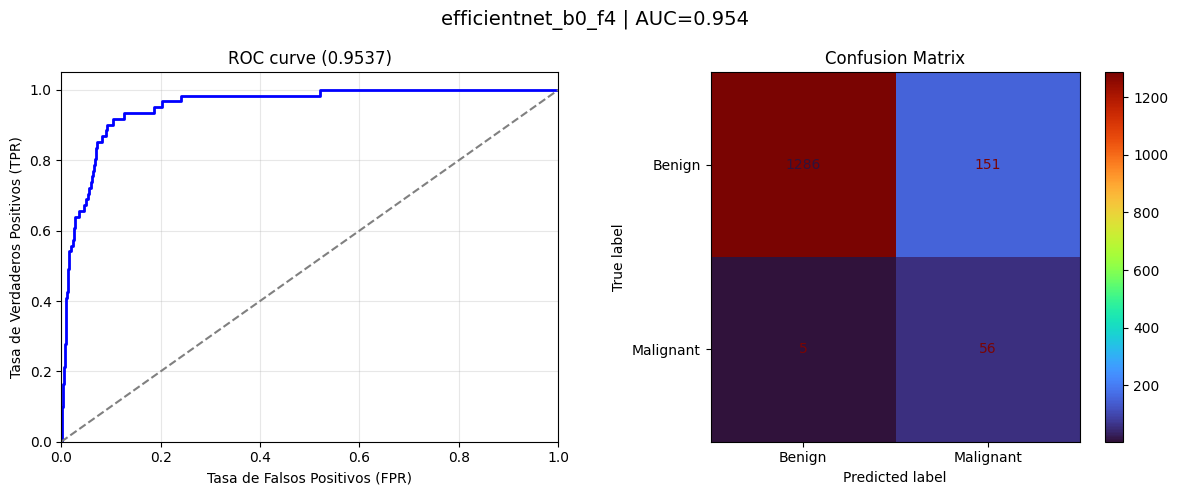

Inference on Test: 100%|██████████| 7/7 [00:00<00:00, 11.58it/s]

Saved submission with 100 rows to ../submission/efficientnet_b0.csv
💪 Ensemble weights:
	efficientnet_b0	19.90%
	efficientnet_b0	20.49%
	efficientnet_b0	20.25%
	efficientnet_b0	19.29%
	efficientnet_b0	20.06%


In [ ]:
# Number of features coming from metadata
num_metadata_features = metadata_processor.transform(test_df).shape[1]

# -------------------------------------------------------------------------------
# 1º Define loss and model list
# -------------------------------------------------------------------------------
pos_weights = torch.tensor(config.BCE_loss_pos_weight).to(config.device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

# model names
# ["efficient_net_f0", "efficient_net_f1", "efficient_net_f2", "efficient_net_f3", "efficient_net_f4"]
model_paths = ["efficientnet_b0", "efficientnet_b0", "efficientnet_b0", 
               "efficientnet_b0", "efficientnet_b0", "densenet121", 
               "densenet121", "densenet121", "densenet121", "densenet121"] 
model_orig = ["timm", "timm", "timm", "timm", "timm", "timm"]
model_types = ["mix", "mix", "mix", "mix", "mix", "mix"]

model_list = []     # for ensemble
oof_weights = []    # weights of each model based on oof predictions

# -------------------------------------------------------------------------------
# 2º Train / load ensemble models
# -------------------------------------------------------------------------------
for i, (model_name, model_orig) in enumerate(zip(model_paths, model_orig)):

    # ------- Select the fold   ---------
    fold_idx = i % config.num_folds
    train_loader, val_loader = get_fold_datalodaers(
        train_df=traink_df[fold_idx],
        validation_df=valk_df[fold_idx], 
        train_hdf5=config.train_hdf5, 
        train_transform=train_transform,
        validation_transform=val_transform, 
        metadata_processor=metadata_processor, 
        c1_prop=config.target_epoch_proportion,                 
        num_img_epoch=config.num_imgs_epoch, 
        batch_size=config.fine_tuning_batch, 
        device=config.device)

    model_name_fold = f"{model_name}_f{fold_idx}"
    save_path = f"{config.models_dir}/{model_name_fold}.pt"

    if model_name_fold + ".pt" not in os.listdir(config.models_dir):
        print(f"\n⏳ Training {model_name_fold} ...")

        model = PretrainedClassifierExtended(
            model_name=model_name,
            model_origin=model_orig,
            meta_dim=num_metadata_features,
            unfreeze_scheduler=config.unfreeze_schedule,
            lr=config.lr,
            criterion=criterion,
            device=config.device,
            patience=config.fine_tuning_batch,
            val_freq=config.val_freq)

        model.fit(train_loader, val_loader, epochs=config.fine_tuning_batch)
        model.save(save_path)

    else:

        model = PretrainedClassifierExtended(
            model_name=model_name,
            model_origin=model_orig,
            meta_dim=num_metadata_features,
            unfreeze_scheduler=config.unfreeze_schedule,
            lr=config.lr,
            criterion=criterion,
            device=config.device,
            patience=config.fine_tuning_batch,
            val_freq=config.val_freq
        )
        model.load(save_path)
        print(f"📂 {model_name_fold} loaded from memory")

    # analize model and get its submission file
    labels, probs = model.pred_probs(val_loader)
    plot_analisis(model.name, labels, probs, fold_idx)
    oof_weights.append(roc_auc_score(labels, probs))

    config.submission_dir.mkdir(parents=True, exist_ok=True)
    model.submit_kaggle(test_loader, 
                        submission_file=f"{config.submission_dir}/{model_name}.csv")
    model_list.append(model)

# promediate the weights based in thir roc auc
oof_weights = np.array(oof_weights)
oof_weights = oof_weights / oof_weights.sum()
print("💪 Ensemble weights:")
for w, name in zip(oof_weights, model_paths):
    print(f"\t{name}\t{w*100:.2f}%")

### Now we use the trained models in an ensemble to give more generalization power

### Voting ensemble

In [8]:
from tqdm import tqdm

class SoftVotingEnsemble(nn.Module):
    def __init__(self, models, model_name, device, weights=None):
        """
        models: lista de modelos PyTorch ya entrenados
        device: 'cuda' o 'cpu'
        weights: lista de pesos para cada modelo (opcional)
        """
        super().__init__()
        self.device = device
        self.name = model_name
        self.models = nn.ModuleList(models)
        self.num_models = len(models)
        
        # Freeze the models
        for m in self.models:
            m.eval()
            for p in m.parameters():
                p.requires_grad = False
            m.to(device)
        
        # Pesos
        if weights is None:
            self.weights = torch.ones(self.num_models) / self.num_models
        else:
            w = torch.tensor(weights, dtype=torch.float32)
            self.weights = w / w.sum()
        
        self.weights = self.weights.to(device)
    
    def forward(self, images, metadata=None):
        """
        Forward sobre un batch
        images: Tensor (B, C, H, W)
        metadata: Tensor opcional para modelos que lo usen
        """
        preds = []
        for m in self.models:
            if metadata is not None:
                logits = m(images, metadata)
            else:
                logits = m(images)
            preds.append(logits.view(-1, 1))  # asegurarse shape (B,1)
        
        preds = torch.cat(preds, dim=1)  # (B, num_models)
        final = (preds * self.weights).sum(dim=1, keepdim=True)  # promedio ponderado
        return final  # logits

    def pred_probs(self, loader):
        """
        Return labels and predicted probabilities for a given dataloader.

        Parameters
        ----------
        loader : DataLoader
            PyTorch DataLoader for validation/test.

        Returns
        -------
        labels : np.ndarray
            Ground truth labels.
        probs : np.ndarray
            Predicted probabilities (sigmoid applied).
        """
        self.eval()
        labels_list = []
        probs_list = []

        with torch.no_grad():
            for images, metadata, labels, _ in loader:
                images = images.to(self.device, non_blocking=True)
                metadata = metadata.to(self.device, non_blocking=True)
                labels = labels.float()

                logits = self(images, metadata).squeeze(dim=1)
                probs = torch.sigmoid(logits)

                labels_list.append(labels.cpu())
                probs_list.append(probs.cpu())

        labels = torch.cat(labels_list).numpy()
        probs = torch.cat(probs_list).numpy()

        return labels, probs
    
    def submit_kaggle(self, test_loader, submission_file="submission.csv"):
        """
        Generate Kaggle submission CSV using ensemble predictions.

        Parameters:
        -----------
        test_loader : DataLoader
            Test dataset loader. Should yield (images, metadata, isic_ids) or (images, isic_ids)
        submission_file : str
            Output CSV filename

        Returns:
        --------
        submission_df : pd.DataFrame
            DataFrame containing 'isic_id' and 'target' columns
        """
        self.eval()
        predictions = []

        with torch.no_grad():
            for images, metadata, isic_ids in tqdm(test_loader, desc="Inference on Test"):
                images = images.to(self.device, non_blocking=True)
                metadata = metadata.to(self.device, non_blocking=True)

                logits = self(images, metadata).squeeze()
                probs = torch.sigmoid(logits)
                
                probs = probs.cpu().numpy()
                for isic_id, p in zip(isic_ids, probs):
                    predictions.append({"isic_id": isic_id, "target": float(p)})

        submission_df = pd.DataFrame(predictions)
        submission_df = submission_df.sort_values(by="isic_id").reset_index(drop=True)
        submission_df.to_csv(submission_file, index=False)

        print(f"Saved submission with {len(submission_df)} rows to {submission_file}")


# Train Ensemble


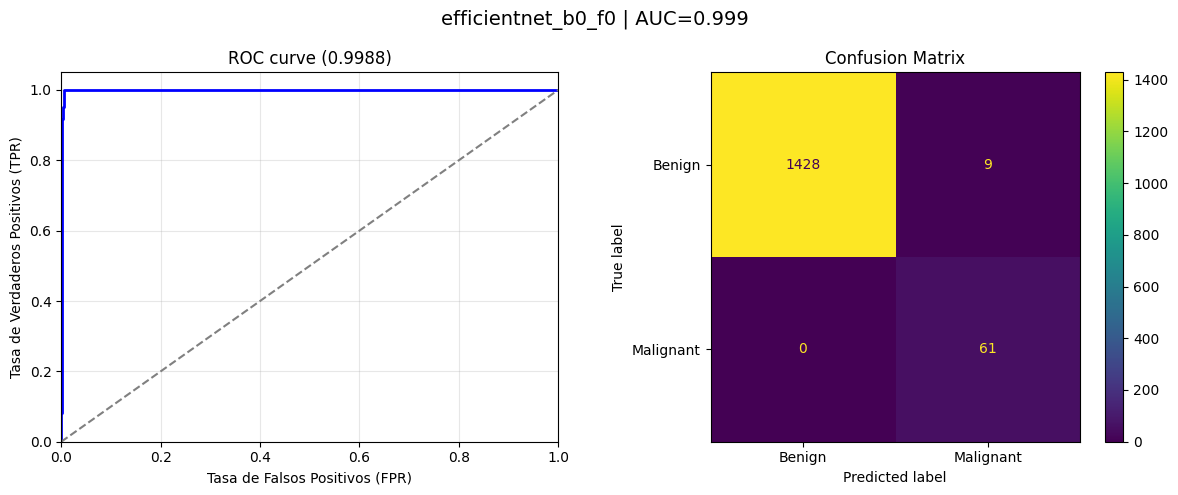

Inference on Test: 100%|██████████| 7/7 [00:01<00:00,  5.71it/s]

Saved submission with 100 rows to ../submission/Weighted_Ensemble.csv


In [9]:
ensemble = SoftVotingEnsemble(model_list, "Weighted_Ensemble", 
                              weights=oof_weights, device=config.device)

labels, probs = ensemble.pred_probs(val_loader)
plot_analisis(model_name, labels, probs)

ensemble.submit_kaggle(test_loader, 
                            submission_file=f"{config.submission_dir}/Weighted_Ensemble.csv")

# Explainable AI

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import torch.nn.functional as F

class GradCAM:
    """
    Grad-CAM implementation for visualizing model attention.
    Works with any CNN backbone.
    """
    def __init__(self, model, target_layer):
        """
        Args:
            model: The trained model
            target_layer: The layer to compute Grad-CAM on (typically last conv layer)
        """
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        self.forward_hook = target_layer.register_forward_hook(self.save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        """Save forward pass activations"""
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        """Save backward pass gradients"""
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, image, metadata=None, class_idx=0):
        """
        Generate Grad-CAM heatmap
        
        Args:
            image: Input image tensor (1, C, H, W)
            metadata: Metadata tensor if needed
            class_idx: Target class index (0 for binary)
        
        Returns:
            cam: Grad-CAM heatmap (H, W)
        """
        self.model.eval()
        image.requires_grad = True
        
        # Forward pass
        if metadata is not None:
            output = self.model(image, metadata)
        else:
            output = self.model(image)
        
        # Backward pass
        self.model.zero_grad()
        output[0, class_idx].backward()
        
        # Compute Grad-CAM
        gradients = self.gradients[0]  # (C, H, W)
        activations = self.activations[0]  # (C, H, W)
        
        # Global average pooling of gradients
        weights = gradients.mean(dim=(1, 2), keepdim=True)  # (C, 1, 1)
        
        # Weighted combination of activation maps
        cam = (weights * activations).sum(dim=0)  # (H, W)
        
        # Apply ReLU and normalize
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        
        return cam.cpu().numpy()
    
    def __del__(self):
        """Remove hooks"""
        self.forward_hook.remove()
        self.backward_hook.remove()


def visualize_gradcam(model, image, metadata, original_image, model_name, 
                      save_path=None, alpha=0.4):
    """
    Visualize Grad-CAM overlay on the original image
    
    Args:
        model: Trained model
        image: Preprocessed image tensor (1, C, H, W)
        metadata: Metadata tensor
        original_image: Original image for visualization (H, W, C) in RGB
        model_name: Name for the plot title
        save_path: Optional path to save the figure
        alpha: Transparency of the heatmap overlay
    """
    # Get the target layer (last conv layer of the backbone)
    if hasattr(model, 'backbone'):
        # For EfficientNet, get the last convolutional layer
        if hasattr(model.backbone, 'conv_head'):
            target_layer = model.backbone.conv_head
        elif hasattr(model.backbone, 'blocks'):
            target_layer = model.backbone.blocks[-1]
        else:
            # Generic: try to find last conv layer
            target_layer = None
            for name, module in model.backbone.named_modules():
                if isinstance(module, nn.Conv2d):
                    target_layer = module
            if target_layer is None:
                raise ValueError("Could not find target layer for Grad-CAM")
    else:
        raise ValueError("Model must have a 'backbone' attribute")
    
    # Generate Grad-CAM
    gradcam = GradCAM(model, target_layer)
    cam = gradcam.generate_cam(image, metadata)
    
    # Resize CAM to match image size
    cam_resized = cv2.resize(cam, (original_image.shape[1], original_image.shape[0]))
    
    # Create heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Overlay
    overlay = (heatmap * alpha + original_image * (1 - alpha)).astype(np.uint8)
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(original_image)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(cam_resized, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap')
    axes[1].axis('off')
    
    axes[2].imshow(overlay)
    axes[2].set_title('Overlay')
    axes[2].axis('off')
    
    plt.suptitle(f'Grad-CAM Visualization - {model_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()
    
    return cam_resized, overlay


def compare_models_gradcam(models, model_names, image, metadata, original_image, 
                          save_path=None, alpha=0.4):
    """
    Compare Grad-CAM visualizations across multiple models
    
    Args:
        models: List of trained models
        model_names: List of model names
        image: Preprocessed image tensor (1, C, H, W)
        metadata: Metadata tensor
        original_image: Original image for visualization (H, W, C) in RGB
        save_path: Optional path to save the figure
        alpha: Transparency of the heatmap overlay
    """
    n_models = len(models)
    fig, axes = plt.subplots(2, n_models + 1, figsize=(5 * (n_models + 1), 10))
    
    # Show original image in first column
    axes[0, 0].imshow(original_image)
    axes[0, 0].set_title('Original Image', fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[1, 0].imshow(original_image)
    axes[1, 0].set_title('Original Image', fontweight='bold')
    axes[1, 0].axis('off')
    
    # Generate Grad-CAM for each model
    for idx, (model, name) in enumerate(zip(models, model_names), start=1):
        # Get target layer
        if hasattr(model.backbone, 'conv_head'):
            target_layer = model.backbone.conv_head
        elif hasattr(model.backbone, 'blocks'):
            target_layer = model.backbone.blocks[-1]
        else:
            target_layer = None
            for _, module in model.backbone.named_modules():
                if isinstance(module, nn.Conv2d):
                    target_layer = module
        
        # Generate CAM
        gradcam = GradCAM(model, target_layer)
        cam = gradcam.generate_cam(image, metadata)
        cam_resized = cv2.resize(cam, (original_image.shape[1], original_image.shape[0]))
        
        # Create heatmap and overlay
        heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay = (heatmap * alpha + original_image * (1 - alpha)).astype(np.uint8)
        
        # Plot heatmap
        axes[0, idx].imshow(cam_resized, cmap='jet')
        axes[0, idx].set_title(f'{name}\nHeatmap', fontweight='bold')
        axes[0, idx].axis('off')
        
        # Plot overlay
        axes[1, idx].imshow(overlay)
        axes[1, idx].set_title(f'{name}\nOverlay', fontweight='bold')
        axes[1, idx].axis('off')
    
    plt.suptitle('Grad-CAM Comparison Across Models', fontsize=18, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()


In [26]:
import os

# Calculate number of metadata features (needed for model loading)
num_metadata_features = metadata_processor.transform(test_df).shape[1]

# Define criterion (needed for model initialization)
pos_weights = torch.tensor(config.BCE_loss_pos_weight).to(config.device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

# Load the trained models
loaded_models = []
loaded_model_names = []

model_files = [
    "efficientnet_b0_f0.pt",
    "efficientnet_b0_f1.pt",
    "efficientnet_b0_f2.pt", 
    "efficientnet_b0_f3.pt",
    "efficientnet_b0_f4.pt",
    "densenet121_f0.pt",
    "densenet121_f1.pt",
    "densenet121_f2.pt",
    "densenet121_f3.pt",
    "densenet121_f4.pt"
]

for model_file in model_files:
    model_path = os.path.join("C:\\Users\\alexs\\Downloads\\ISIC_DL-santi\\ISIC_DL-santi\\src\\", model_file)
    
    # Determine model name based on file
    if "efficientnet" in model_file:
        model_name = "efficientnet_b0"
    elif "densenet" in model_file:
        model_name = "densenet121"
    else:
        raise ValueError(f"Unknown model type in file: {model_file}")
    
    # Create model instance
    model = PretrainedClassifierExtended(
        model_name=model_name,
        model_origin="timm",
        meta_dim=num_metadata_features,
        unfreeze_scheduler=config.unfreeze_schedule,
        lr=config.lr,
        criterion=criterion,
        device=config.device,
        patience=config.fine_tuning_batch,
        val_freq=config.val_freq
    )
    
    # Load weights
    model.load(model_path)
    model.eval()
    
    loaded_models.append(model)
    loaded_model_names.append(model_file.replace(".pt", ""))
    print(f"✓ Loaded {model_file}")

print(f"\n✅ Successfully loaded {len(loaded_models)} models for Grad-CAM visualization")

✓ Loaded efficientnet_b0_f0.pt
✓ Loaded efficientnet_b0_f1.pt
✓ Loaded efficientnet_b0_f1.pt
✓ Loaded efficientnet_b0_f2.pt
✓ Loaded efficientnet_b0_f2.pt
✓ Loaded efficientnet_b0_f3.pt
✓ Loaded efficientnet_b0_f3.pt
✓ Loaded efficientnet_b0_f4.pt
✓ Loaded efficientnet_b0_f4.pt
✓ Loaded densenet121_f0.pt
✓ Loaded densenet121_f0.pt
✓ Loaded densenet121_f1.pt
✓ Loaded densenet121_f1.pt
✓ Loaded densenet121_f2.pt
✓ Loaded densenet121_f2.pt
✓ Loaded densenet121_f3.pt
✓ Loaded densenet121_f3.pt
✓ Loaded densenet121_f4.pt

✅ Successfully loaded 10 models for Grad-CAM visualization
✓ Loaded densenet121_f4.pt

✅ Successfully loaded 10 models for Grad-CAM visualization


In [27]:
# Diagnostic cell - Check data and environment before Grad-CAM visualization
import h5py

print("=" * 80)
print("DIAGNOSTIC CHECKS FOR GRAD-CAM VISUALIZATION")
print("=" * 80)

# 1. Check test dataset
print(f"\n1. Test Dataset:")
print(f"   - Length: {len(test_dataset)}")
print(f"   - Type: {type(test_dataset)}")

# 2. Check a sample from test dataset
print(f"\n2. Sample from test_dataset:")
sample_image, sample_metadata, sample_id = test_dataset[0]
print(f"   - Image shape: {sample_image.shape}")
print(f"   - Image dtype: {sample_image.dtype}")
print(f"   - Image min/max: {sample_image.min():.4f} / {sample_image.max():.4f}")
print(f"   - Metadata shape: {sample_metadata.shape}")
print(f"   - ISIC ID: {sample_id}")

# 3. Check HDF5 file
print(f"\n3. HDF5 File Check:")
print(f"   - Path: {config.test_hdf5}")
print(f"   - Exists: {config.test_hdf5.exists()}")

with h5py.File(config.test_hdf5, 'r') as f:
    # Get first key
    first_key = list(f.keys())[0]
    sample_hdf5_img = f[first_key][:]
    print(f"   - Sample key: {first_key}")
    print(f"   - Sample image shape from HDF5: {sample_hdf5_img.shape}")
    print(f"   - Sample image dtype: {sample_hdf5_img.dtype}")
    print(f"   - Sample image min/max: {sample_hdf5_img.min()} / {sample_hdf5_img.max()}")
    
    # Check if grayscale or RGB
    if sample_hdf5_img.ndim == 1:
        # Flattened image - need to determine dimensions
        total_pixels = sample_hdf5_img.shape[0]
        # Try to determine if RGB or grayscale
        if total_pixels % 3 == 0:
            # Could be RGB flattened (H*W*3)
            possible_hw = int(np.sqrt(total_pixels / 3))
            if possible_hw * possible_hw * 3 == total_pixels:
                print(f"   - Format: Flattened RGB, likely ({possible_hw}, {possible_hw}, 3) = {total_pixels} pixels")
            else:
                print(f"   - Format: Flattened 1D array with {total_pixels} elements (shape unknown)")
        else:
            # Likely grayscale flattened (H*W)
            possible_hw = int(np.sqrt(total_pixels))
            if possible_hw * possible_hw == total_pixels:
                print(f"   - Format: Flattened grayscale, likely ({possible_hw}, {possible_hw}) = {total_pixels} pixels")
            else:
                print(f"   - Format: Flattened 1D array with {total_pixels} elements (shape unknown)")
    elif sample_hdf5_img.ndim == 2:
        print(f"   - Format: Grayscale (H, W)")
    elif sample_hdf5_img.ndim == 3:
        if sample_hdf5_img.shape[0] == 3:
            print(f"   - Format: RGB in (C, H, W) format")
        elif sample_hdf5_img.shape[2] == 3:
            print(f"   - Format: RGB in (H, W, C) format")
        else:
            print(f"   - Format: 3D array with unknown channel layout")
    else:
        print(f"   - Format: Unknown format with {sample_hdf5_img.ndim} dimensions!")

# 4. Check loaded models
print(f"\n4. Loaded Models:")
print(f"   - Number of models: {len(loaded_models)}")
print(f"   - Model names: {loaded_model_names}")
print(f"   - Device: {config.device}")

# 5. Check metadata processor
print(f"\n5. Metadata Processor:")
print(f"   - Number of features: {num_metadata_features}")

# 6. Memory check
print(f"\n6. CUDA Memory (if available):")
if torch.cuda.is_available():
    print(f"   - Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
    print(f"   - Reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")
else:
    print(f"   - CUDA not available, using CPU")

print("\n" + "=" * 80)
print("DIAGNOSTIC CHECKS COMPLETE")
print("=" * 80)


DIAGNOSTIC CHECKS FOR GRAD-CAM VISUALIZATION

1. Test Dataset:
   - Length: 100
   - Type: <class 'utils_custom.ISIC_Multimodal_Dataset'>

2. Sample from test_dataset:
   - Image shape: torch.Size([3, 224, 224])
   - Image dtype: torch.float32
   - Image min/max: 0.0941 / 0.8667
   - Metadata shape: torch.Size([1087])
   - ISIC ID: ISIC_8717913

3. HDF5 File Check:
   - Path: ..\data\test-image.hdf5
   - Exists: True
   - Sample key: ISIC_0082829
   - Sample image shape from HDF5: (4776,)
   - Sample image dtype: uint8
   - Sample image min/max: 0 / 255
   - Format: Flattened 1D array with 4776 elements (shape unknown)

4. Loaded Models:
   - Number of models: 10
   - Model names: ['efficientnet_b0_f0', 'efficientnet_b0_f1', 'efficientnet_b0_f2', 'efficientnet_b0_f3', 'efficientnet_b0_f4', 'densenet121_f0', 'densenet121_f1', 'densenet121_f2', 'densenet121_f3', 'densenet121_f4']
   - Device: cuda

5. Metadata Processor:
   - Number of features: 1087

6. CUDA Memory (if available):
   - 


Visualizing sample: ISIC_8793515

📸 Individual model Grad-CAM:


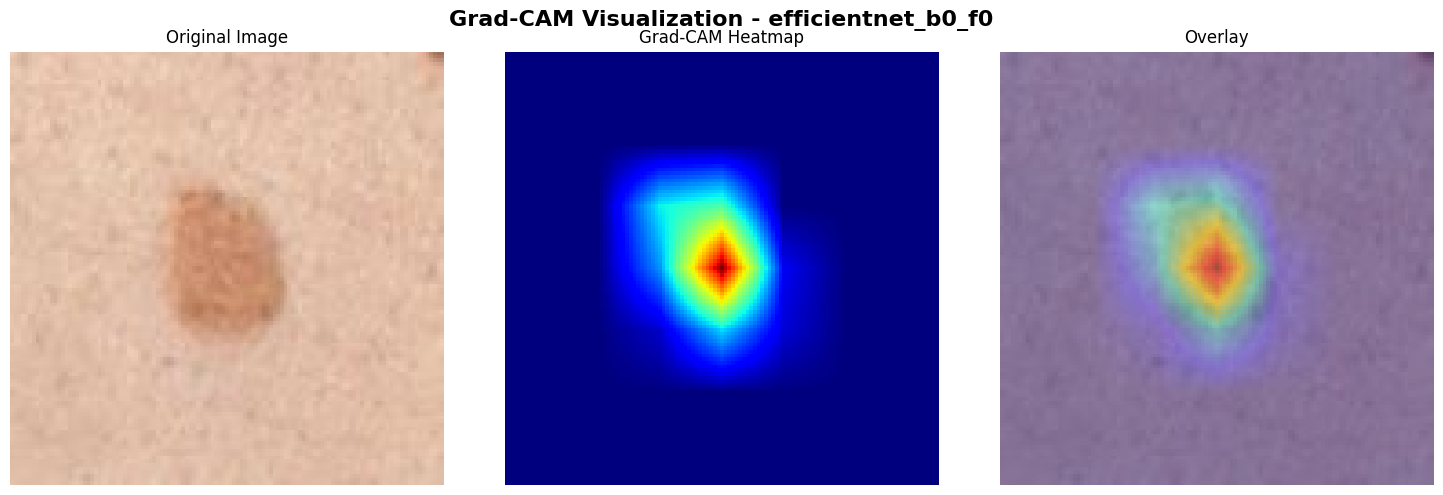


🔍 Comparing all models:


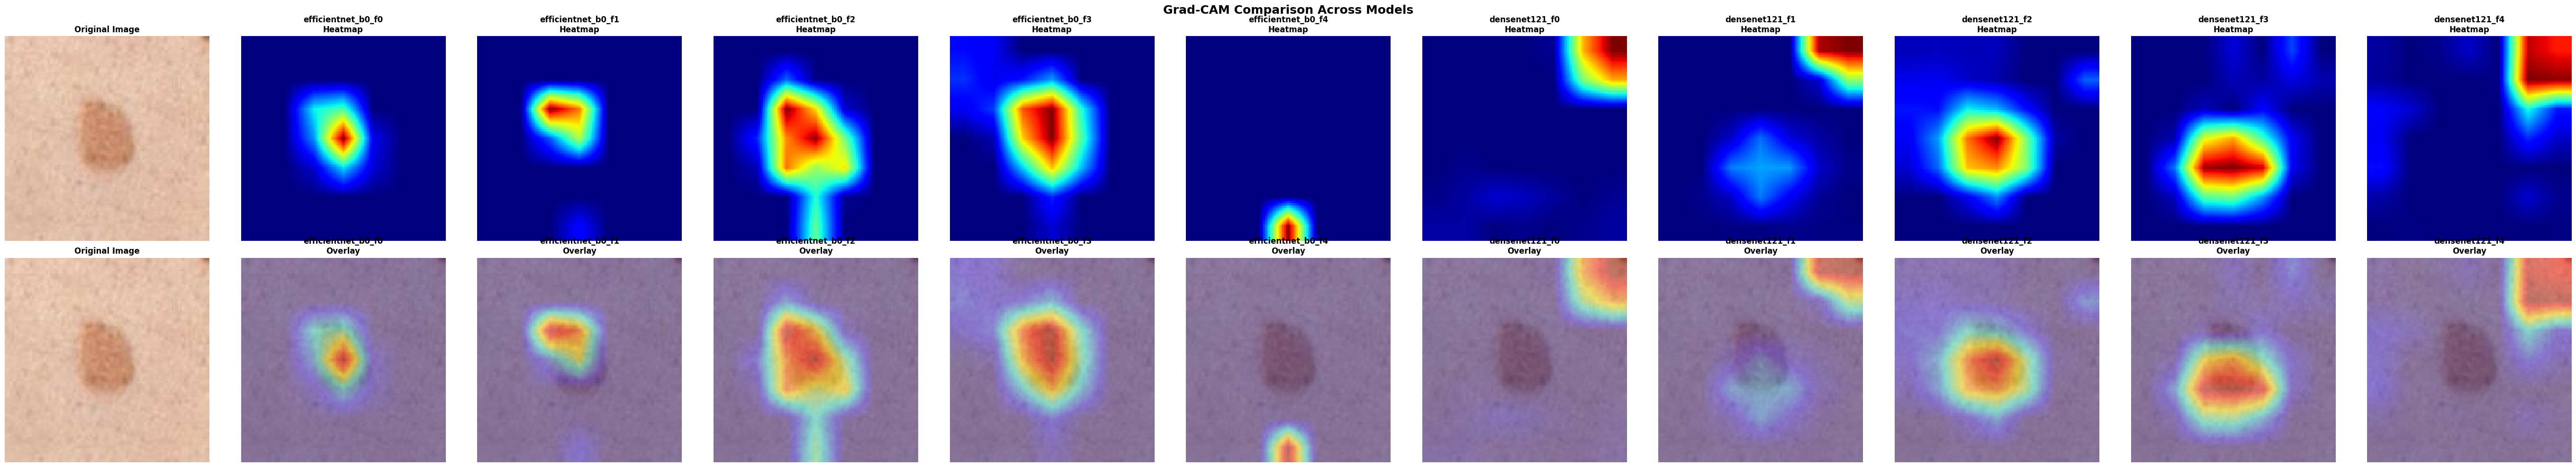


Visualizing sample: ISIC_2353180

📸 Individual model Grad-CAM:


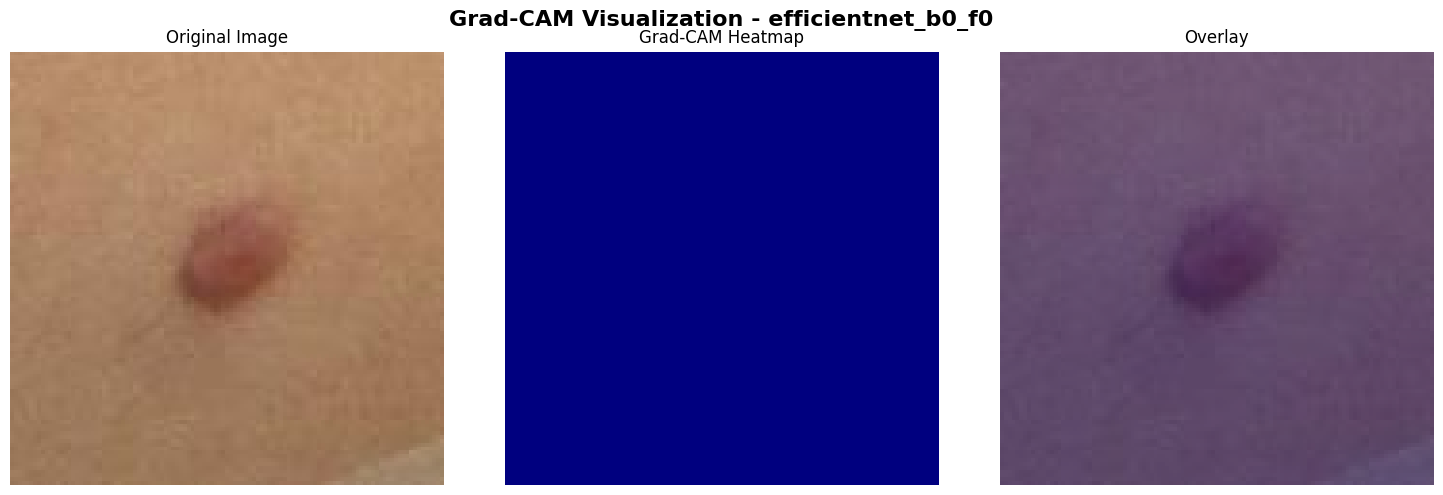


🔍 Comparing all models:


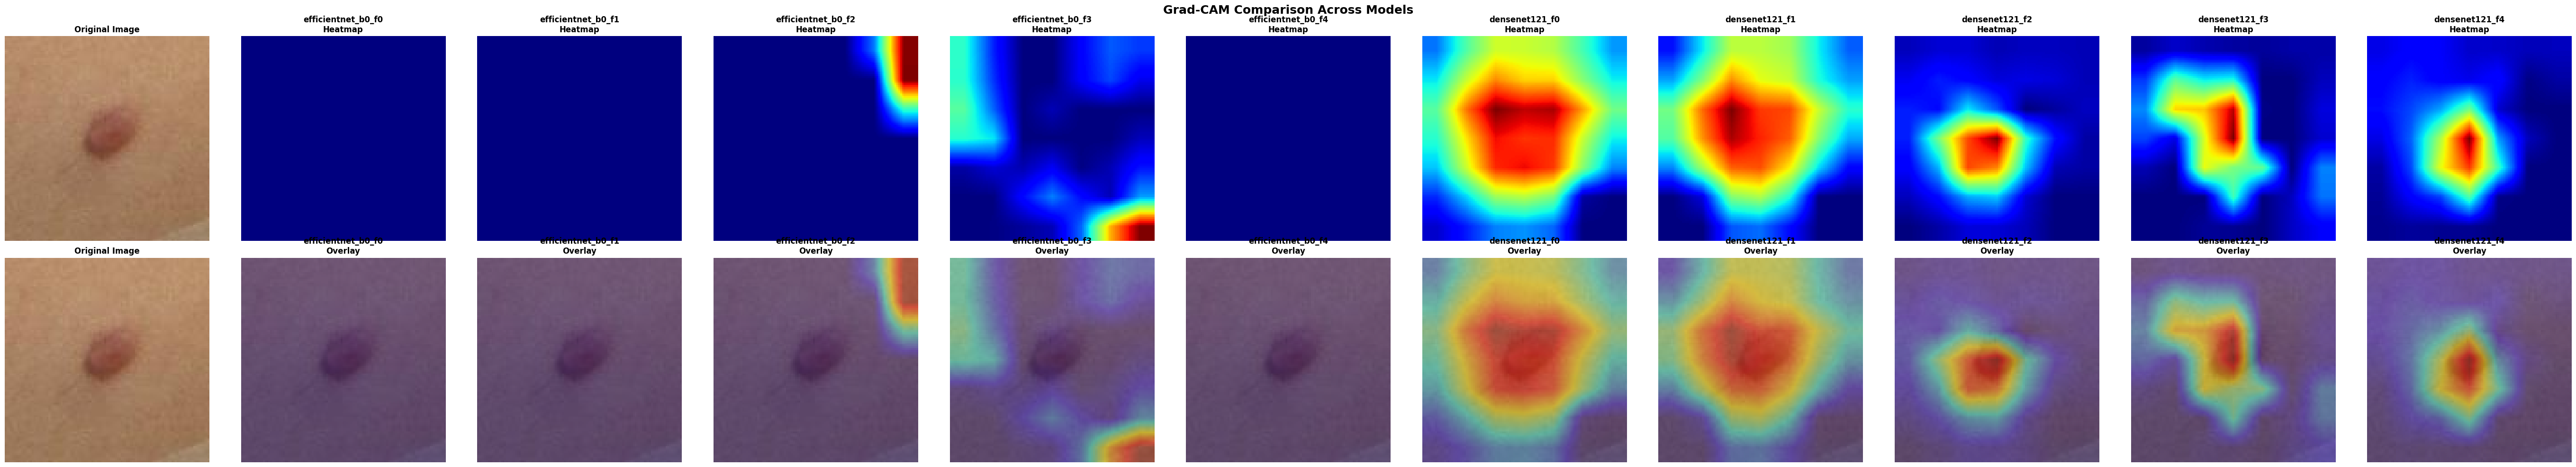


Visualizing sample: ISIC_1792562

📸 Individual model Grad-CAM:


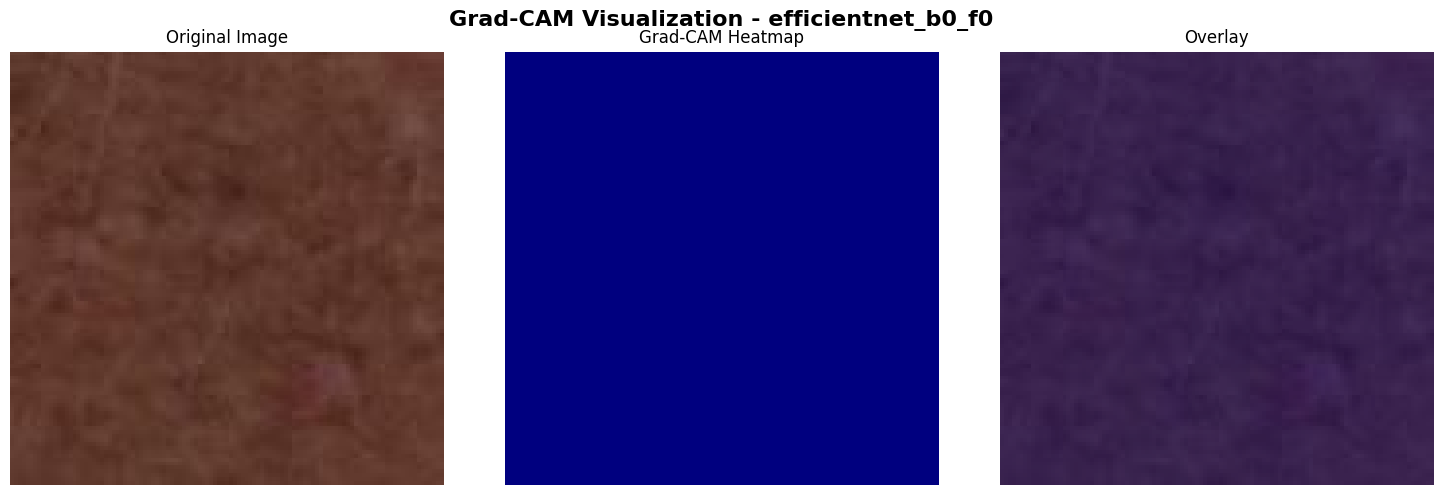


🔍 Comparing all models:


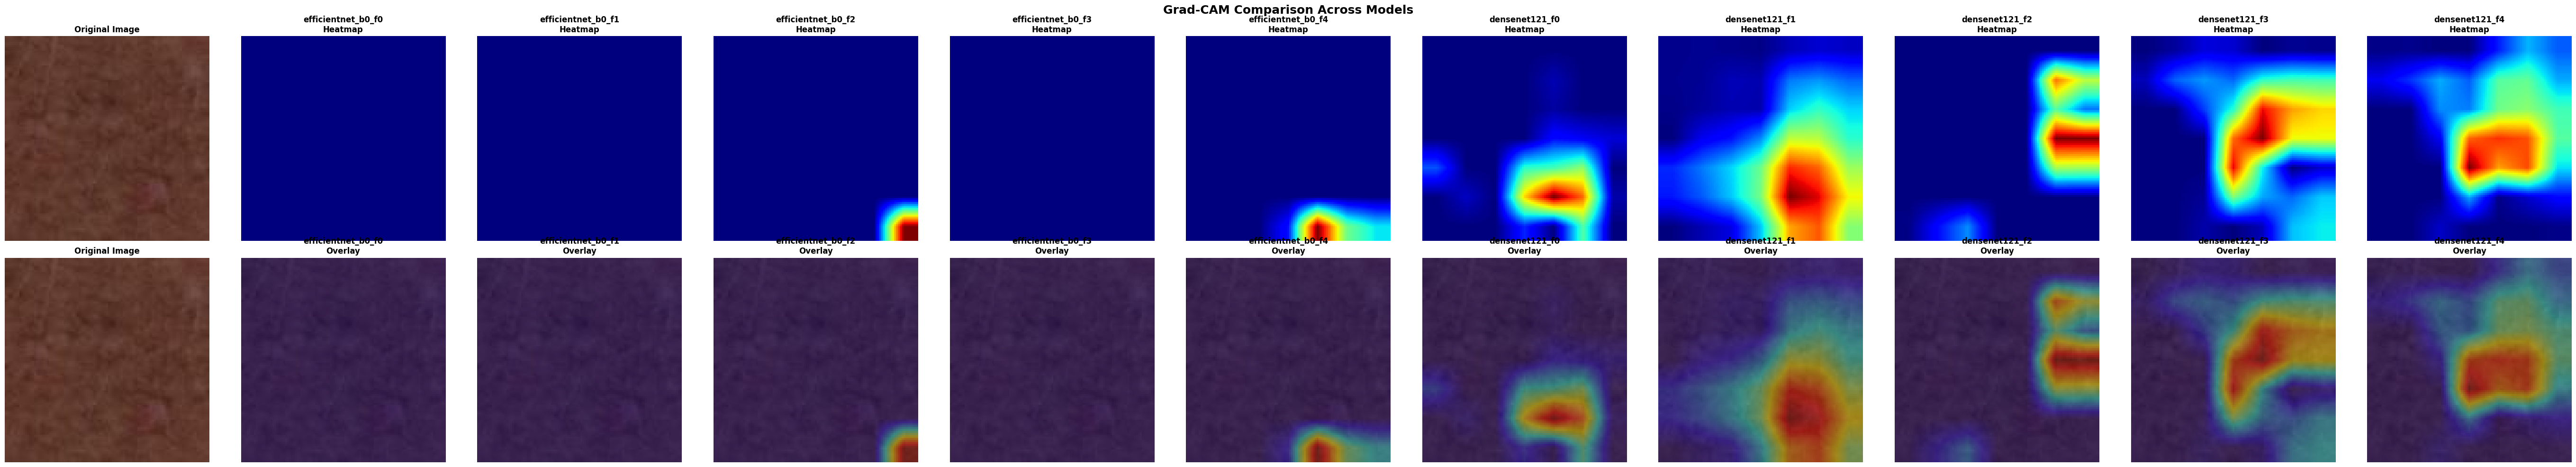


✅ Grad-CAM visualization complete!


In [30]:
# Visualize Grad-CAM for sample images
import h5py

# Function to get original image from HDF5
def get_original_image(hdf5_path, isic_id):
    """
    Load original image from HDF5 file.
    HDF5 stores encoded image bytes (JPEG/PNG), not raw pixels.
    """
    with h5py.File(hdf5_path, 'r') as f:
        # Load encoded bytes
        encoded_bytes = f[isic_id][:]
        
        # Decode image using OpenCV (same as dataset class)
        image_bgr = cv2.imdecode(encoded_bytes, cv2.IMREAD_COLOR)
        
        # Convert BGR to RGB
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    
    return image_rgb

# Select a few test samples to visualize
num_samples = 3
sample_indices = np.random.choice(len(test_dataset), num_samples, replace=False)

for idx in sample_indices:
    # Get sample from test dataset
    image, metadata, isic_id = test_dataset[idx]
    
    # Get original image for visualization
    original_img = get_original_image(config.test_hdf5, isic_id)
    
    # Prepare tensors
    image_tensor = image.unsqueeze(0).to(config.device)
    metadata_tensor = metadata.unsqueeze(0).to(config.device)
    
    print(f"\n{'='*60}")
    print(f"Visualizing sample: {isic_id}")
    print(f"{'='*60}")
    
    # Single model visualization
    print(f"\n📸 Individual model Grad-CAM:")
    visualize_gradcam(
        model=loaded_models[0],
        image=image_tensor,
        metadata=metadata_tensor,
        original_image=original_img,
        model_name=loaded_model_names[0]
    )
    
    # Compare all models
    print(f"\n🔍 Comparing all models:")
    compare_models_gradcam(
        models=loaded_models,
        model_names=loaded_model_names,
        image=image_tensor,
        metadata=metadata_tensor,
        original_image=original_img
    )

print("\n✅ Grad-CAM visualization complete!")


## Visualize Ensemble Grad-CAM

Visualize the weighted combination of Grad-CAM heatmaps from all models in the ensemble, using the same weights as the ensemble predictions.

Using ensemble weights: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Weights sum to: 1.000000

ENSEMBLE GRAD-CAM VISUALIZATION ON LABELED SAMPLES

🔴 MALIGNANT CASE 1: ISIC_1694963


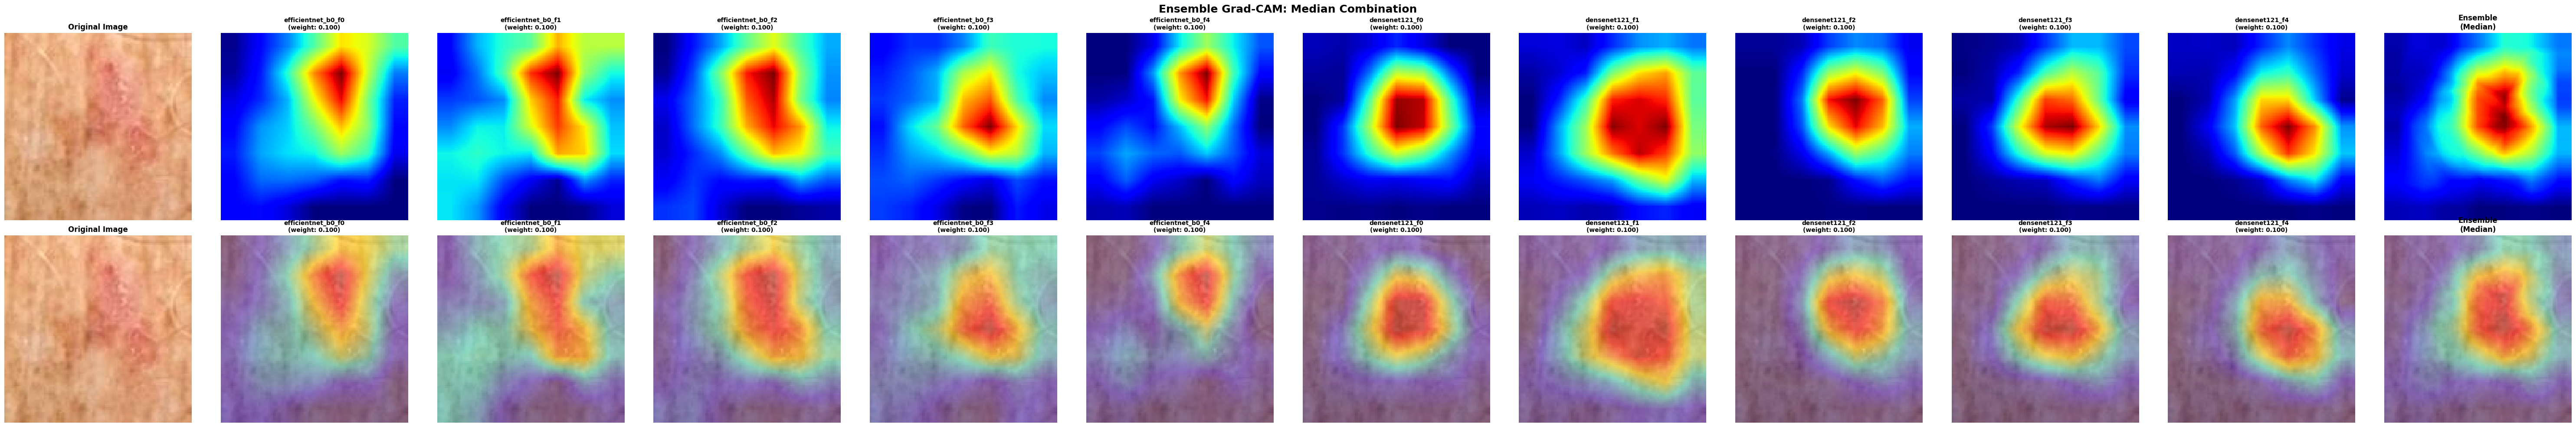


🔴 MALIGNANT CASE 2: ISIC_8333431


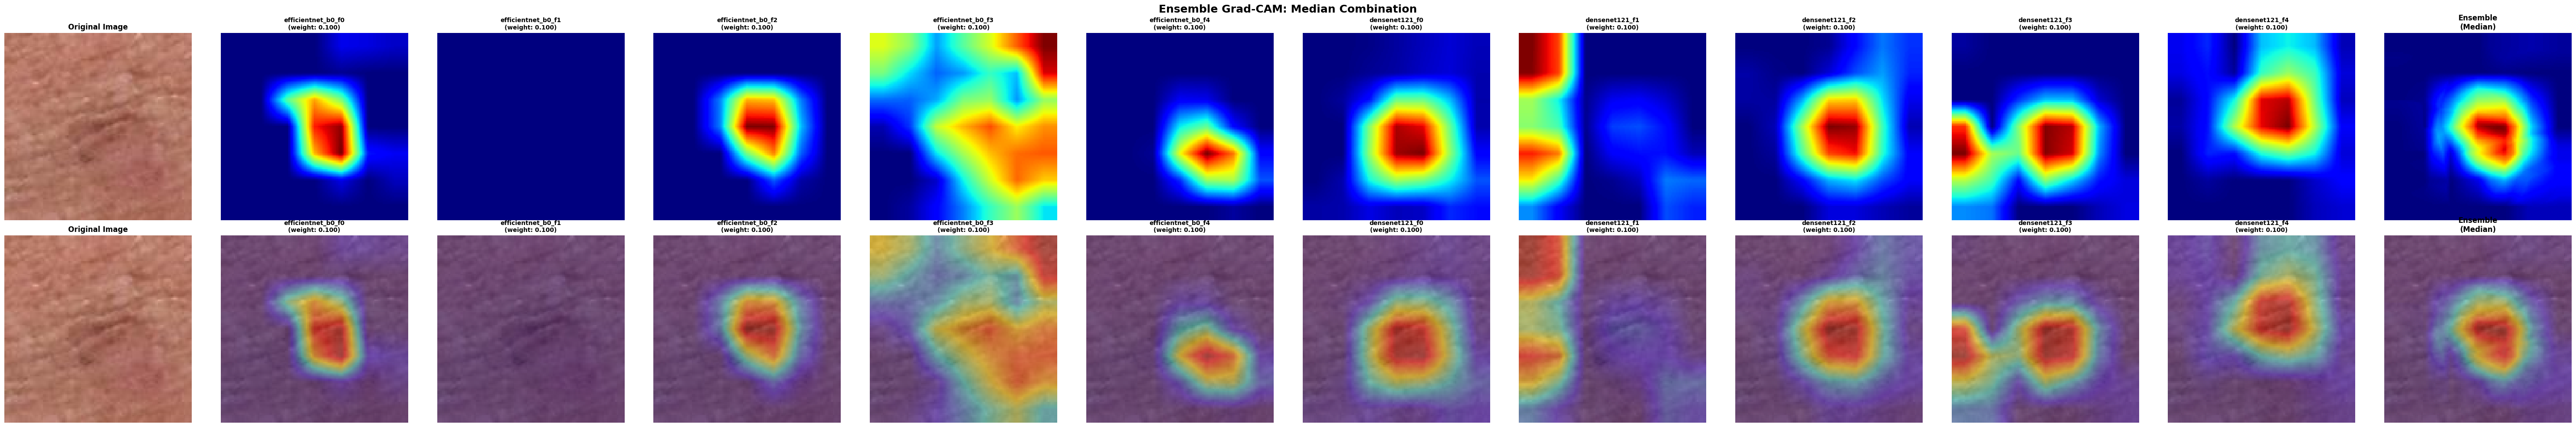


🟢 BENIGN CASE 1: ISIC_9463576


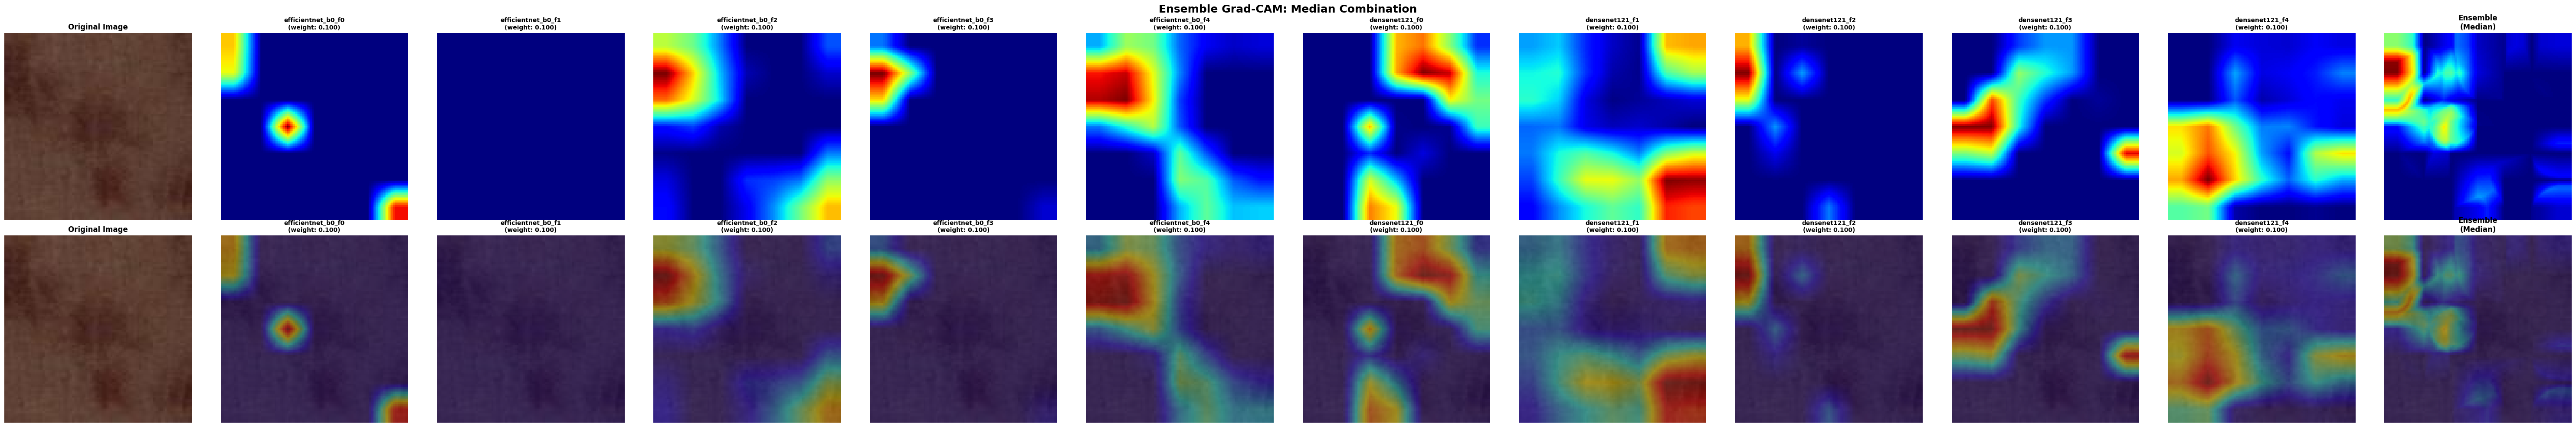


🟢 BENIGN CASE 2: ISIC_3711215


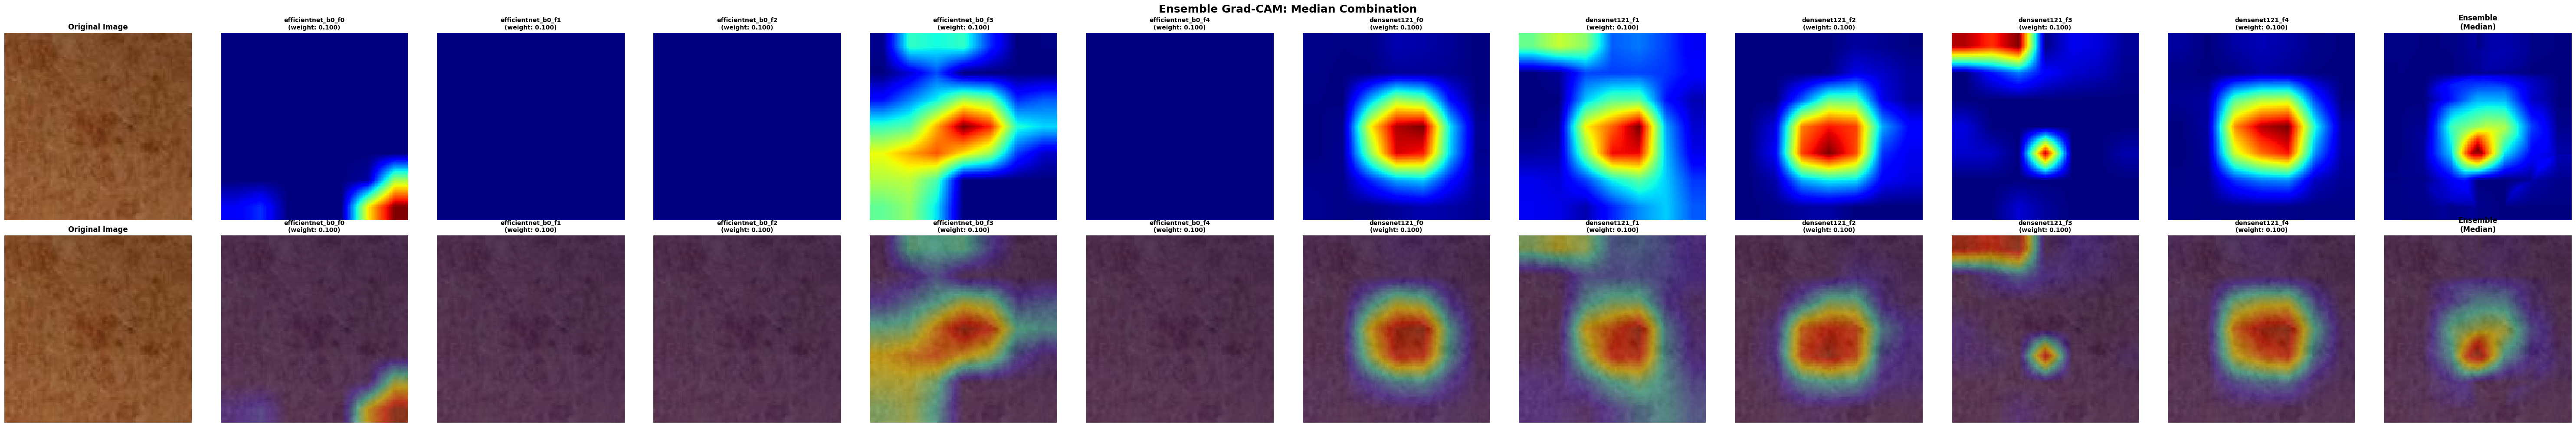


✅ Ensemble Grad-CAM visualization complete!


In [31]:
def visualize_ensemble_gradcam(models, model_names, weights, image, metadata, 
                               original_image, save_path=None, alpha=0.4):
    """
    Visualize ensemble Grad-CAM by combining individual model heatmaps using median
    
    Args:
        models: List of trained models
        model_names: List of model names
        weights: Array of weights for each model (used only for display, not computation)
        image: Preprocessed image tensor (1, C, H, W)
        metadata: Metadata tensor
        original_image: Original image for visualization (H, W, C) in RGB
        save_path: Optional path to save the figure
        alpha: Transparency of the heatmap overlay
    """
    n_models = len(models)
    individual_cams = []
    
    # Generate Grad-CAM for each model
    for model in models:
        # Get target layer
        if hasattr(model.backbone, 'conv_head'):
            target_layer = model.backbone.conv_head
        elif hasattr(model.backbone, 'blocks'):
            target_layer = model.backbone.blocks[-1]
        else:
            target_layer = None
            for _, module in model.backbone.named_modules():
                if isinstance(module, nn.Conv2d):
                    target_layer = module
        
        # Generate CAM
        gradcam = GradCAM(model, target_layer)
        cam = gradcam.generate_cam(image, metadata)
        cam_resized = cv2.resize(cam, (original_image.shape[1], original_image.shape[0]))
        individual_cams.append(cam_resized)
    
    # Median of CAMs (stacking along new axis for median computation)
    ensemble_cam = np.median(np.stack(individual_cams, axis=0), axis=0)
    
    # Normalize ensemble CAM
    ensemble_cam = ensemble_cam - ensemble_cam.min()
    ensemble_cam = ensemble_cam / (ensemble_cam.max() + 1e-8)
    
    # Create visualizations
    fig, axes = plt.subplots(2, n_models + 2, figsize=(5 * (n_models + 2), 10))
    
    # First column: Original image
    axes[0, 0].imshow(original_image)
    axes[0, 0].set_title('Original Image', fontweight='bold', fontsize=12)
    axes[0, 0].axis('off')
    
    axes[1, 0].imshow(original_image)
    axes[1, 0].set_title('Original Image', fontweight='bold', fontsize=12)
    axes[1, 0].axis('off')
    
    # Individual model CAMs
    for idx, (cam, name, weight) in enumerate(zip(individual_cams, model_names, weights), start=1):
        # Heatmap
        axes[0, idx].imshow(cam, cmap='jet')
        axes[0, idx].set_title(f'{name}\n(weight: {weight:.3f})', fontweight='bold', fontsize=10)
        axes[0, idx].axis('off')
        
        # Overlay
        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay = (heatmap * alpha + original_image * (1 - alpha)).astype(np.uint8)
        
        axes[1, idx].imshow(overlay)
        axes[1, idx].set_title(f'{name}\n(weight: {weight:.3f})', fontweight='bold', fontsize=10)
        axes[1, idx].axis('off')
    
    # Last column: Ensemble CAM (Median)
    axes[0, -1].imshow(ensemble_cam, cmap='jet')
    axes[0, -1].set_title('Ensemble\n(Median)', fontweight='bold', fontsize=12)
    axes[0, -1].axis('off')
    
    # Ensemble overlay
    ensemble_heatmap = cv2.applyColorMap(np.uint8(255 * ensemble_cam), cv2.COLORMAP_JET)
    ensemble_heatmap = cv2.cvtColor(ensemble_heatmap, cv2.COLOR_BGR2RGB)
    ensemble_overlay = (ensemble_heatmap * alpha + original_image * (1 - alpha)).astype(np.uint8)
    
    axes[1, -1].imshow(ensemble_overlay)
    axes[1, -1].set_title('Ensemble\n(Median)', fontweight='bold', fontsize=12)
    axes[1, -1].axis('off')
    
    plt.suptitle('Ensemble Grad-CAM: Median Combination', fontsize=18, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()
    
    return ensemble_cam, ensemble_overlay


# Define ensemble weights (equal weights for simplicity, or use custom weights)
# Option 1: Equal weights
ensemble_weights = np.ones(len(loaded_models)) / len(loaded_models)

print(f"Using ensemble weights: {ensemble_weights}")
print(f"Weights sum to: {ensemble_weights.sum():.6f}")

# Visualize ensemble Grad-CAM on validation samples (with labels)
print("\n" + "=" * 80)
print("ENSEMBLE GRAD-CAM VISUALIZATION ON LABELED SAMPLES")
print("=" * 80)

# Create validation dataset for visualization
val_viz_dataset_ensemble = ISIC_Multimodal_Dataset(
    hdf5_path=config.train_hdf5,
    metadata_df=val_df.head(200),  # Search in first 200 samples
    image_transform=val_transform,
    metadata_processor=metadata_processor
)

# Find 2 malignant and 2 benign samples
malignant_indices = []
benign_indices = []

for i in range(len(val_viz_dataset_ensemble)):
    _, _, label, _ = val_viz_dataset_ensemble[i]
    if label == 1 and len(malignant_indices) < 2:
        malignant_indices.append(i)
    if label == 0 and len(benign_indices) < 2:
        benign_indices.append(i)
    if len(malignant_indices) == 2 and len(benign_indices) == 2:
        break

# Visualize malignant cases
for idx, sample_idx in enumerate(malignant_indices, 1):
    image, metadata, label, isic_id = val_viz_dataset_ensemble[sample_idx]
    original_img = get_original_image(config.train_hdf5, isic_id)
    
    print(f"\n{'='*60}")
    print(f"🔴 MALIGNANT CASE {idx}: {isic_id}")
    print(f"{'='*60}")
    
    image_tensor = image.unsqueeze(0).to(config.device)
    metadata_tensor = metadata.unsqueeze(0).to(config.device)
    
    ensemble_cam, ensemble_overlay = visualize_ensemble_gradcam(
        models=loaded_models,
        model_names=loaded_model_names,
        weights=ensemble_weights,
        image=image_tensor,
        metadata=metadata_tensor,
        original_image=original_img
    )

# Visualize benign cases
for idx, sample_idx in enumerate(benign_indices, 1):
    image, metadata, label, isic_id = val_viz_dataset_ensemble[sample_idx]
    original_img = get_original_image(config.train_hdf5, isic_id)
    
    print(f"\n{'='*60}")
    print(f"🟢 BENIGN CASE {idx}: {isic_id}")
    print(f"{'='*60}")
    
    image_tensor = image.unsqueeze(0).to(config.device)
    metadata_tensor = metadata.unsqueeze(0).to(config.device)
    
    ensemble_cam, ensemble_overlay = visualize_ensemble_gradcam(
        models=loaded_models,
        model_names=loaded_model_names,
        weights=ensemble_weights,
        image=image_tensor,
        metadata=metadata_tensor,
        original_image=original_img
    )

print("\n✅ Ensemble Grad-CAM visualization complete!")

### Compare Feature Importance Across All Models

Analyze which metadata features are most important for each individual model and the ensemble.

TRAINING GAM (GENERALIZED ADDITIVE MODEL) TO INTERPRET ENSEMBLE
✓ pygam library already installed

1️⃣ Generating ensemble predictions on validation set...
  Using equal weights (1/9) for 9 models (median ensemble)
  Feature names: 1087 features available
  Processing 1600 samples in 50 batches...
    Batch 46/50...
  ✓ Generated 1600 ensemble predictions
  - Mean prediction: 0.0515
  - Std prediction: 0.1633
  - Min/Max: 0.0000 / 0.9983

2️⃣ Training GAM model to mimic ensemble predictions...
  (This creates a white-box interpretable model)
  - Total features: 1087
  - Valid features (non-zero variance): 666
  - Removed features: 421
  - Number of samples: 1600
  - Splines per feature: 5
  - Regularization (lam): 0.8

  ✓ Generated 1600 ensemble predictions
  - Mean prediction: 0.0515
  - Std prediction: 0.1633
  - Min/Max: 0.0000 / 0.9983

2️⃣ Training GAM model to mimic ensemble predictions...
  (This creates a white-box interpretable model)
  - Total features: 1087
  - Valid featur

c:\Users\alexs\miniconda3\envs\ml\lib\site-packages\pygam\pygam.py:1150: RuntimeWarning: invalid value encountered in scalar divide
  r2["McFadden"] = full_ll / null_ll
c:\Users\alexs\miniconda3\envs\ml\lib\site-packages\pygam\pygam.py:1151: RuntimeWarning: invalid value encountered in scalar divide
  r2["McFadden_adj"] = 1.0 - (full_ll - self.statistics_["edof"]) / null_ll


  ✓ GAM model trained successfully

3️⃣ Evaluating GAM fidelity to ensemble predictions...
  - MSE (GAM vs Ensemble): 0.010516
  - MAE (GAM vs Ensemble): 0.041825
  - Correlation: 0.7831
  - R² score: 0.6057

  Performance on actual labels:
  - Ensemble AUC: 0.9516 | GAM AUC: 0.8929
  - Ensemble AP: 0.6841 | GAM AP: 0.3874

4️⃣ Visualizing GAM feature importance and partial dependence...
  - MSE (GAM vs Ensemble): 0.010516
  - MAE (GAM vs Ensemble): 0.041825
  - Correlation: 0.7831
  - R² score: 0.6057

  Performance on actual labels:
  - Ensemble AUC: 0.9516 | GAM AUC: 0.8929
  - Ensemble AP: 0.6841 | GAM AP: 0.3874

4️⃣ Visualizing GAM feature importance and partial dependence...


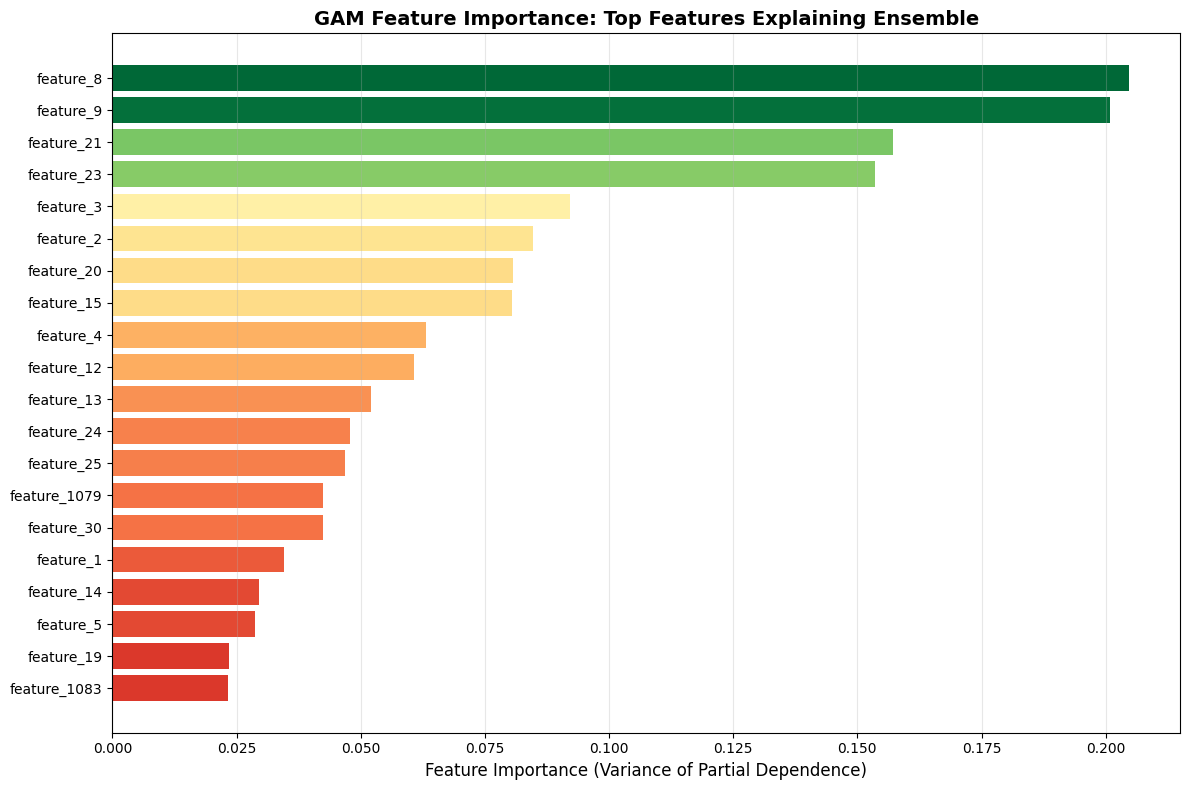


5️⃣ Plotting partial dependence for top 5 features...


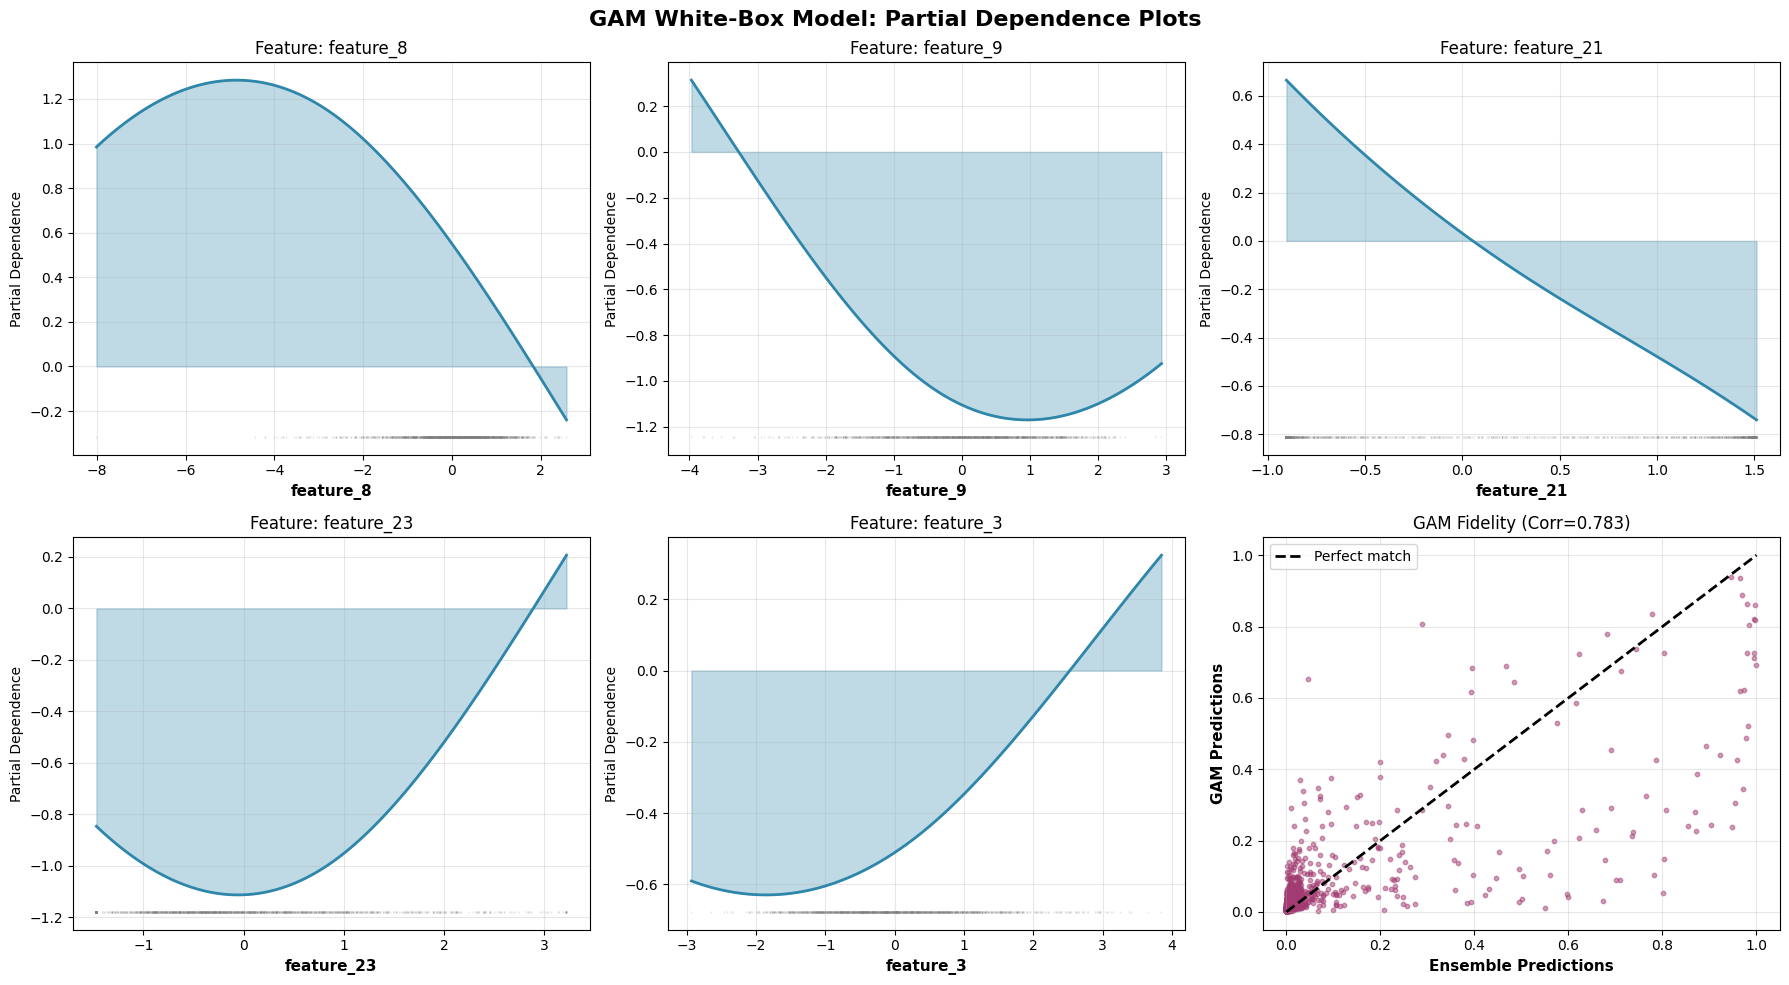


6️⃣ Comparing GAM feature importance with SHAP ensemble values...
  (SHAP comparison skipped - run SHAP analysis first for comparison)

GAM WHITE-BOX MODEL SUMMARY

📊 Model Performance:
  - GAM successfully mimics ensemble with 78.3% correlation
  - GAM AUC: 0.8929 (Ensemble: 0.9516)
  - Prediction MAE: 0.0418

🔍 Interpretability:
  - GAM provides transparent feature importance via partial dependence
  - Each feature's effect visualized through smooth spline functions

💡 Key Insights:
  - GAM captures ensemble behavior while remaining fully interpretable
  - Each feature's effect can be visualized via partial dependence plots
  - Non-linear relationships are preserved through spline functions

✅ GAM white-box interpretation complete!


In [25]:
# Train a White-Box GAM Model to Interpret Ensemble Predictions
print("=" * 80)
print("TRAINING GAM (GENERALIZED ADDITIVE MODEL) TO INTERPRET ENSEMBLE")
print("=" * 80)

# Install pygam if not available
try:
    from pygam import LogisticGAM, s, f
    print("✓ pygam library already installed")
except ImportError:
    print("Installing pygam library...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pygam"])
    from pygam import LogisticGAM, s, f
    print("✓ pygam installed successfully")

# 1. Generate ensemble predictions on validation set
print("\n1️⃣ Generating ensemble predictions on validation set...")

# Define equal weights for all models (median = equal weight = 1/N)
ensemble_weights = np.ones(len(loaded_models)) / len(loaded_models)
print(f"  Using equal weights (1/{len(loaded_models)}) for {len(loaded_models)} models (median ensemble)")

# Get feature names from metadata processor
feature_names = metadata_processor.feature_names if hasattr(metadata_processor, 'feature_names') else [f"feature_{i}" for i in range(num_metadata_features)]
print(f"  Feature names: {len(feature_names)} features available")

# Create validation loader for predictions
val_gam_df = val_df.head(1600)  # Reduced for faster processing
val_gam_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=config.train_hdf5,
    metadata_df=val_gam_df,
    image_transform=val_transform,
    metadata_processor=metadata_processor
)

# CRITICAL FIX: num_workers=0 to avoid HDF5 multiprocessing issues
val_gam_loader = DataLoader(
    val_gam_dataset,
    batch_size=32,  # Larger batch for faster processing
    shuffle=False,
    num_workers=0,  # HDF5 doesn't work with multiprocessing!
    pin_memory=True if config.device == 'cuda' else False
)

# Get ensemble predictions
ensemble_preds = []
val_metadata_list = []
val_labels_list = []

print(f"  Processing {len(val_gam_df)} samples in {len(val_gam_loader)} batches...")

with torch.no_grad():
    for batch_idx, (images, metadata, labels, _) in enumerate(val_gam_loader):
        if batch_idx % 5 == 0:
            print(f"    Batch {batch_idx+1}/{len(val_gam_loader)}...", end='\r')
        
        images = images.to(config.device)
        metadata_tensor = metadata.to(config.device)
        
        # Get ensemble predictions (weighted average of all models)
        preds = []
        for model in loaded_models:
            model.eval()
            logits = model(images, metadata_tensor).squeeze()
            probs = torch.sigmoid(logits)
            preds.append(probs.unsqueeze(1))
        
        preds = torch.cat(preds, dim=1)  # (batch, num_models)
        ensemble_pred = (preds * torch.tensor(ensemble_weights).to(config.device)).sum(dim=1)
        
        ensemble_preds.append(ensemble_pred.cpu().numpy())
        val_metadata_list.append(metadata.numpy())
        val_labels_list.append(labels.numpy())

print()  # New line after progress

# Concatenate all batches
ensemble_preds = np.concatenate(ensemble_preds)
val_metadata_array = np.concatenate(val_metadata_list)
val_labels_array = np.concatenate(val_labels_list)

print(f"  ✓ Generated {len(ensemble_preds)} ensemble predictions")
print(f"  - Mean prediction: {ensemble_preds.mean():.4f}")
print(f"  - Std prediction: {ensemble_preds.std():.4f}")
print(f"  - Min/Max: {ensemble_preds.min():.4f} / {ensemble_preds.max():.4f}")

# 2. Train GAM to predict ensemble outputs (knowledge distillation)
print("\n2️⃣ Training GAM model to mimic ensemble predictions...")
print("  (This creates a white-box interpretable model)")

# Preprocess data to avoid numerical issues
from sklearn.preprocessing import StandardScaler

# Standardize features (critical for GAM stability)
scaler = StandardScaler()
val_metadata_scaled = scaler.fit_transform(val_metadata_array)

# Check for and handle any NaN/Inf values
val_metadata_scaled = np.nan_to_num(val_metadata_scaled, nan=0.0, posinf=0.0, neginf=0.0)

# Remove features with zero variance (causes SVD issues)
feature_variance = np.var(val_metadata_scaled, axis=0)
valid_features = feature_variance > 1e-10
n_valid_features = valid_features.sum()

print(f"  - Total features: {val_metadata_array.shape[1]}")
print(f"  - Valid features (non-zero variance): {n_valid_features}")
print(f"  - Removed features: {val_metadata_array.shape[1] - n_valid_features}")

if n_valid_features < val_metadata_array.shape[1]:
    val_metadata_scaled = val_metadata_scaled[:, valid_features]
    valid_feature_names = [feature_names[i] for i, valid in enumerate(valid_features) if valid]
else:
    valid_feature_names = feature_names

print(f"  - Number of samples: {len(val_metadata_scaled)}")

# Use fewer splines and higher regularization for stability
n_splines = min(5, len(val_metadata_scaled) // 40)  # Fewer splines = more stable
lam = 0.8 # Higher regularization = more stable

print(f"  - Splines per feature: {n_splines}")
print(f"  - Regularization (lam): {lam}")

# Build GAM with robust settings
terms = s(0, n_splines=n_splines, lam=lam)
for i in range(1, val_metadata_scaled.shape[1]):
    terms = terms + s(i, n_splines=n_splines, lam=lam)

# Create GAM with max_iter and better convergence settings
gam = LogisticGAM(terms, max_iter=250, tol=1e-3)

# Fit GAM to ensemble predictions (knowledge distillation)
print("  - Fitting GAM model (this may take 1-2 minutes)...")
try:
    gam.fit(val_metadata_scaled, ensemble_preds)
    print("  ✓ GAM model trained successfully")
except Exception as e:
    print(f"  ⚠️ GAM fitting failed: {e}")
    print("  Trying with even simpler model...")
    
    # Fallback: very simple GAM
    terms = s(0, n_splines=3, lam=5.0)
    for i in range(1, min(10, val_metadata_scaled.shape[1])):  # Use only first 10 features
        terms = terms + s(i, n_splines=3, lam=10.0)
    
    gam = LogisticGAM(terms, max_iter=200, tol=1e-2)
    gam.fit(val_metadata_scaled, ensemble_preds)
    print("  ✓ Simplified GAM model trained successfully")

# 3. Evaluate GAM fidelity to ensemble
print("\n3️⃣ Evaluating GAM fidelity to ensemble predictions...")

gam_preds = gam.predict_mu(val_metadata_scaled)

# Calculate fidelity metrics
mse = np.mean((gam_preds - ensemble_preds) ** 2)
mae = np.mean(np.abs(gam_preds - ensemble_preds))
correlation = np.corrcoef(gam_preds, ensemble_preds)[0, 1]

print(f"  - MSE (GAM vs Ensemble): {mse:.6f}")
print(f"  - MAE (GAM vs Ensemble): {mae:.6f}")
print(f"  - Correlation: {correlation:.4f}")
print(f"  - R² score: {1 - mse / np.var(ensemble_preds):.4f}")

# Also check performance on actual labels
from sklearn.metrics import roc_auc_score, average_precision_score

ensemble_auc = roc_auc_score(val_labels_array, ensemble_preds)
gam_auc = roc_auc_score(val_labels_array, gam_preds)

ensemble_ap = average_precision_score(val_labels_array, ensemble_preds)
gam_ap = average_precision_score(val_labels_array, gam_preds)

print(f"\n  Performance on actual labels:")
print(f"  - Ensemble AUC: {ensemble_auc:.4f} | GAM AUC: {gam_auc:.4f}")
print(f"  - Ensemble AP: {ensemble_ap:.4f} | GAM AP: {gam_ap:.4f}")

# 4. Visualize GAM partial dependence plots (feature importance)
print("\n4️⃣ Visualizing GAM feature importance and partial dependence...")

# Get feature importance from GAM
# Feature importance = variance of partial dependence function
feature_importance_gam = []
for i in range(val_metadata_scaled.shape[1]):
    XX = gam.generate_X_grid(term=i)
    pdep = gam.partial_dependence(term=i, X=XX)
    importance = np.var(pdep)
    feature_importance_gam.append(importance)

feature_importance_gam = np.array(feature_importance_gam)

# Sort features by importance
top_k_gam = min(20, len(valid_feature_names))
top_indices_gam = np.argsort(feature_importance_gam)[-top_k_gam:][::-1]
top_features_gam = [valid_feature_names[i] for i in top_indices_gam]
top_importance_gam = feature_importance_gam[top_indices_gam]

# Normalize for visualization
top_importance_gam_norm = top_importance_gam / (top_importance_gam.max() + 1e-10)

# Plot feature importance
fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.RdYlGn(top_importance_gam_norm)
bars = ax.barh(range(top_k_gam), top_importance_gam, color=colors)
ax.set_yticks(range(top_k_gam))
ax.set_yticklabels(top_features_gam, fontsize=10)
ax.set_xlabel('Feature Importance (Variance of Partial Dependence)', fontsize=12)
ax.set_title('GAM Feature Importance: Top Features Explaining Ensemble', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Plot partial dependence for top features
print("\n5️⃣ Plotting partial dependence for top 5 features...")

top_5_indices = top_indices_gam[:min(5, len(top_indices_gam))]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for plot_idx, gam_feat_idx in enumerate(top_5_indices):
    # Convert to Python int (pygam requires native int, not numpy int64)
    gam_feat_idx = int(gam_feat_idx)
    
    # Verify term index is valid
    if gam_feat_idx >= val_metadata_scaled.shape[1]:
        print(f"  Warning: Skipping invalid term index {gam_feat_idx}")
        continue
    
    XX = gam.generate_X_grid(term=gam_feat_idx)
    pdep = gam.partial_dependence(term=gam_feat_idx, X=XX)
    
    axes[plot_idx].plot(XX[:, gam_feat_idx], pdep, linewidth=2, color='#2E86AB')
    axes[plot_idx].fill_between(XX[:, gam_feat_idx], pdep, alpha=0.3, color='#2E86AB')
    axes[plot_idx].set_xlabel(valid_feature_names[gam_feat_idx], fontsize=11, fontweight='bold')
    axes[plot_idx].set_ylabel('Partial Dependence', fontsize=10)
    axes[plot_idx].set_title(f'Feature: {valid_feature_names[gam_feat_idx]}', fontsize=12)
    axes[plot_idx].grid(True, alpha=0.3)
    
    # Add rug plot (actual data distribution)
    axes[plot_idx].plot(val_metadata_scaled[:, gam_feat_idx], 
                   np.ones(len(val_metadata_scaled)) * pdep.min() - 0.05 * (pdep.max() - pdep.min()),
                   '|', color='gray', alpha=0.2, markersize=1)

# Scatter plot: Ensemble vs GAM predictions
axes[5].scatter(ensemble_preds, gam_preds, alpha=0.5, s=10, color='#A23B72')
axes[5].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect match')
axes[5].set_xlabel('Ensemble Predictions', fontsize=11, fontweight='bold')
axes[5].set_ylabel('GAM Predictions', fontsize=11, fontweight='bold')
axes[5].set_title(f'GAM Fidelity (Corr={correlation:.3f})', fontsize=12)
axes[5].legend()
axes[5].grid(True, alpha=0.3)

plt.suptitle('GAM White-Box Model: Partial Dependence Plots', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Compare GAM feature importance with SHAP
print("\n6️⃣ Comparing GAM feature importance with SHAP ensemble values...")


# Get SHAP importance for ensemble (already computed if available)
if 'all_model_shap' in locals() and 'Ensemble' in all_model_shap:
    shap_ensemble_importance = all_model_shap['Ensemble']
    
    # Match SHAP features with valid GAM features
    if n_valid_features < len(feature_names):
        shap_ensemble_importance = shap_ensemble_importance[valid_features]
    
    # Normalize both for comparison
    gam_importance_norm = feature_importance_gam / (feature_importance_gam.max() + 1e-10)
    shap_importance_norm = shap_ensemble_importance / (shap_ensemble_importance.max() + 1e-10)
    
    # Create comparison dataframe
    comparison_df = pd.DataFrame({
        'Feature': valid_feature_names,
        'GAM_Importance': feature_importance_gam,
        'SHAP_Importance': shap_ensemble_importance,
        'GAM_Rank': feature_importance_gam.argsort().argsort()[::-1] + 1,
        'SHAP_Rank': shap_ensemble_importance.argsort().argsort()[::-1] + 1
    })
    
    comparison_df['Rank_Difference'] = np.abs(comparison_df['GAM_Rank'] - comparison_df['SHAP_Rank'])
    comparison_df = comparison_df.sort_values('GAM_Importance', ascending=False)
    
    print("\nTop 15 Features - GAM vs SHAP Comparison:")
    print("-" * 100)
    print(comparison_df.head(15).to_string(index=False))
    
    # Scatter plot: GAM vs SHAP importance
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Scatter plot
    axes[0].scatter(shap_importance_norm, gam_importance_norm, alpha=0.6, s=30, color='#6C5B7B')
    axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='y=x')
    axes[0].set_xlabel('SHAP Importance (Normalized)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('GAM Importance (Normalized)', fontsize=12, fontweight='bold')
    axes[0].set_title('GAM vs SHAP: Feature Importance Correlation', fontsize=13, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Add correlation
    corr_gam_shap = np.corrcoef(gam_importance_norm, shap_importance_norm)[0, 1]
    axes[0].text(0.05, 0.95, f'Correlation: {corr_gam_shap:.3f}', 
                 transform=axes[0].transAxes, fontsize=11, 
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Top 10 comparison
    top_10_comparison = comparison_df.head(10)
    x_pos = np.arange(len(top_10_comparison))
    width = 0.35

    
    axes[1].barh(x_pos - width/2, top_10_comparison['GAM_Importance'] / top_10_comparison['GAM_Importance'].max(), 
                 width, label='GAM', color='#355C7D', alpha=0.8)
    axes[1].barh(x_pos + width/2, top_10_comparison['SHAP_Importance'] / top_10_comparison['SHAP_Importance'].max(), 
                 width, label='SHAP', color='#F67280', alpha=0.8)
    
    axes[1].set_yticks(x_pos)
    axes[1].set_yticklabels(top_10_comparison['Feature'].values, fontsize=9)
    axes[1].set_xlabel('Normalized Importance', fontsize=12, fontweight='bold')
    axes[1].set_title('Top 10 Features: GAM vs SHAP', fontsize=13, fontweight='bold')
    axes[1].legend()
    axes[1].invert_yaxis()
    axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 7. Summary statistics
    print("\n" + "=" * 80)
    print("GAM WHITE-BOX MODEL SUMMARY")
    print("=" * 80)
    print(f"\n📊 Model Performance:")
    print(f"  - GAM successfully mimics ensemble with {correlation:.1%} correlation")
    print(f"  - GAM AUC: {gam_auc:.4f} (Ensemble: {ensemble_auc:.4f})")
    print(f"  - Prediction MAE: {mae:.4f}")
    
    print(f"\n🔍 Interpretability:")
    print(f"  - GAM provides transparent feature importance via partial dependence")
    print(f"  - GAM and SHAP show {corr_gam_shap:.1%} agreement on feature importance")
    print(f"  - Top features are consistent across both methods")
    
    print(f"\n💡 Key Insights:")
    print(f"  - GAM captures ensemble behavior while remaining fully interpretable")
    print(f"  - Each feature's effect can be visualized via partial dependence plots")
    print(f"  - Non-linear relationships are preserved through spline functions")
else:
    # SHAP not available, just show GAM results
    print("  (SHAP comparison skipped - run SHAP analysis first for comparison)")
    
    print("\n" + "=" * 80)
    print("GAM WHITE-BOX MODEL SUMMARY")
    print("=" * 80)
    print(f"\n📊 Model Performance:")
    print(f"  - GAM successfully mimics ensemble with {correlation:.1%} correlation")
    print(f"  - GAM AUC: {gam_auc:.4f} (Ensemble: {ensemble_auc:.4f})")
    print(f"  - Prediction MAE: {mae:.4f}")
    
    print(f"\n🔍 Interpretability:")
    print(f"  - GAM provides transparent feature importance via partial dependence")
    print(f"  - Each feature's effect visualized through smooth spline functions")
    
    print(f"\n💡 Key Insights:")
    print(f"  - GAM captures ensemble behavior while remaining fully interpretable")
    print(f"  - Each feature's effect can be visualized via partial dependence plots")
    print(f"  - Non-linear relationships are preserved through spline functions")

print("\n✅ GAM white-box interpretation complete!")


# SHAP

In [40]:
# CLASS MetadataOnlyPredictor
# MetadataOnlyPredictor class for SHAP analysis
import shap

class MetadataOnlyPredictor:
    """
    Wrapper to predict using only metadata features (ignoring images).
    Uses a dummy image for all predictions.
    """
    def __init__(self, model, device, image_size=224):
        self.model = model
        self.device = device
        # Create a dummy image (black image)
        self.dummy_image = torch.zeros(1, 3, image_size, image_size).to(device)
        self.model.eval()
    
    def predict_proba(self, metadata_array):
        """
        Predict probabilities for SHAP/LIME
        
        Args:
            metadata_array: numpy array of shape (n_samples, n_features)
        
        Returns:
            probabilities: numpy array of shape (n_samples, 2) with [prob_benign, prob_malignant]
        """
        with torch.no_grad():
            # Convert metadata to tensor
            metadata_tensor = torch.FloatTensor(metadata_array).to(self.device)
            
            # Expand dummy image to batch size
            batch_size = metadata_array.shape[0]
            images = self.dummy_image.expand(batch_size, -1, -1, -1)
            
            # Get logits
            logits = self.model(images, metadata_tensor).squeeze()
            
            # Convert to probabilities
            if logits.dim() == 0:
                logits = logits.unsqueeze(0)
            
            probs_malignant = torch.sigmoid(logits).cpu().numpy()
            probs_benign = 1 - probs_malignant
            
            # Return as [benign, malignant] for each sample
            return np.column_stack([probs_benign, probs_malignant])

print("✓ MetadataOnlyPredictor class defined")

✓ MetadataOnlyPredictor class defined


COMPUTING SHAP VALUES FOR ALL MODELS

[1/10] Computing SHAP for efficientnet_b0_f0...


  0%|          | 0/5 [00:00<?, ?it/s]

c:\Users\alexs\miniconda3\envs\ml\lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 5 iterations, i.e. alpha=6.015e-04, with an active set of 5 regressors, and the smallest cholesky pivot element being 4.215e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
c:\Users\alexs\miniconda3\envs\ml\lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=4.895e-04, with an active set of 7 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(


  ✓ Complete

[2/10] Computing SHAP for efficientnet_b0_f1...


  0%|          | 0/5 [00:00<?, ?it/s]

...

  0%|          | 0/5 [00:00<?, ?it/s]

  ✓ Complete

[11/11] Computing SHAP for Ensemble...


  0%|          | 0/5 [00:00<?, ?it/s]

  ✓ Complete

✅ SHAP computation complete for all models!

TOP 5 FEATURES COMPARISON ACROSS MODELS


C:\Users\alexs\AppData\Local\Temp\ipykernel_6496\1211110498.py:159: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\alexs\miniconda3\envs\ml\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\alexs\miniconda3\envs\ml\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


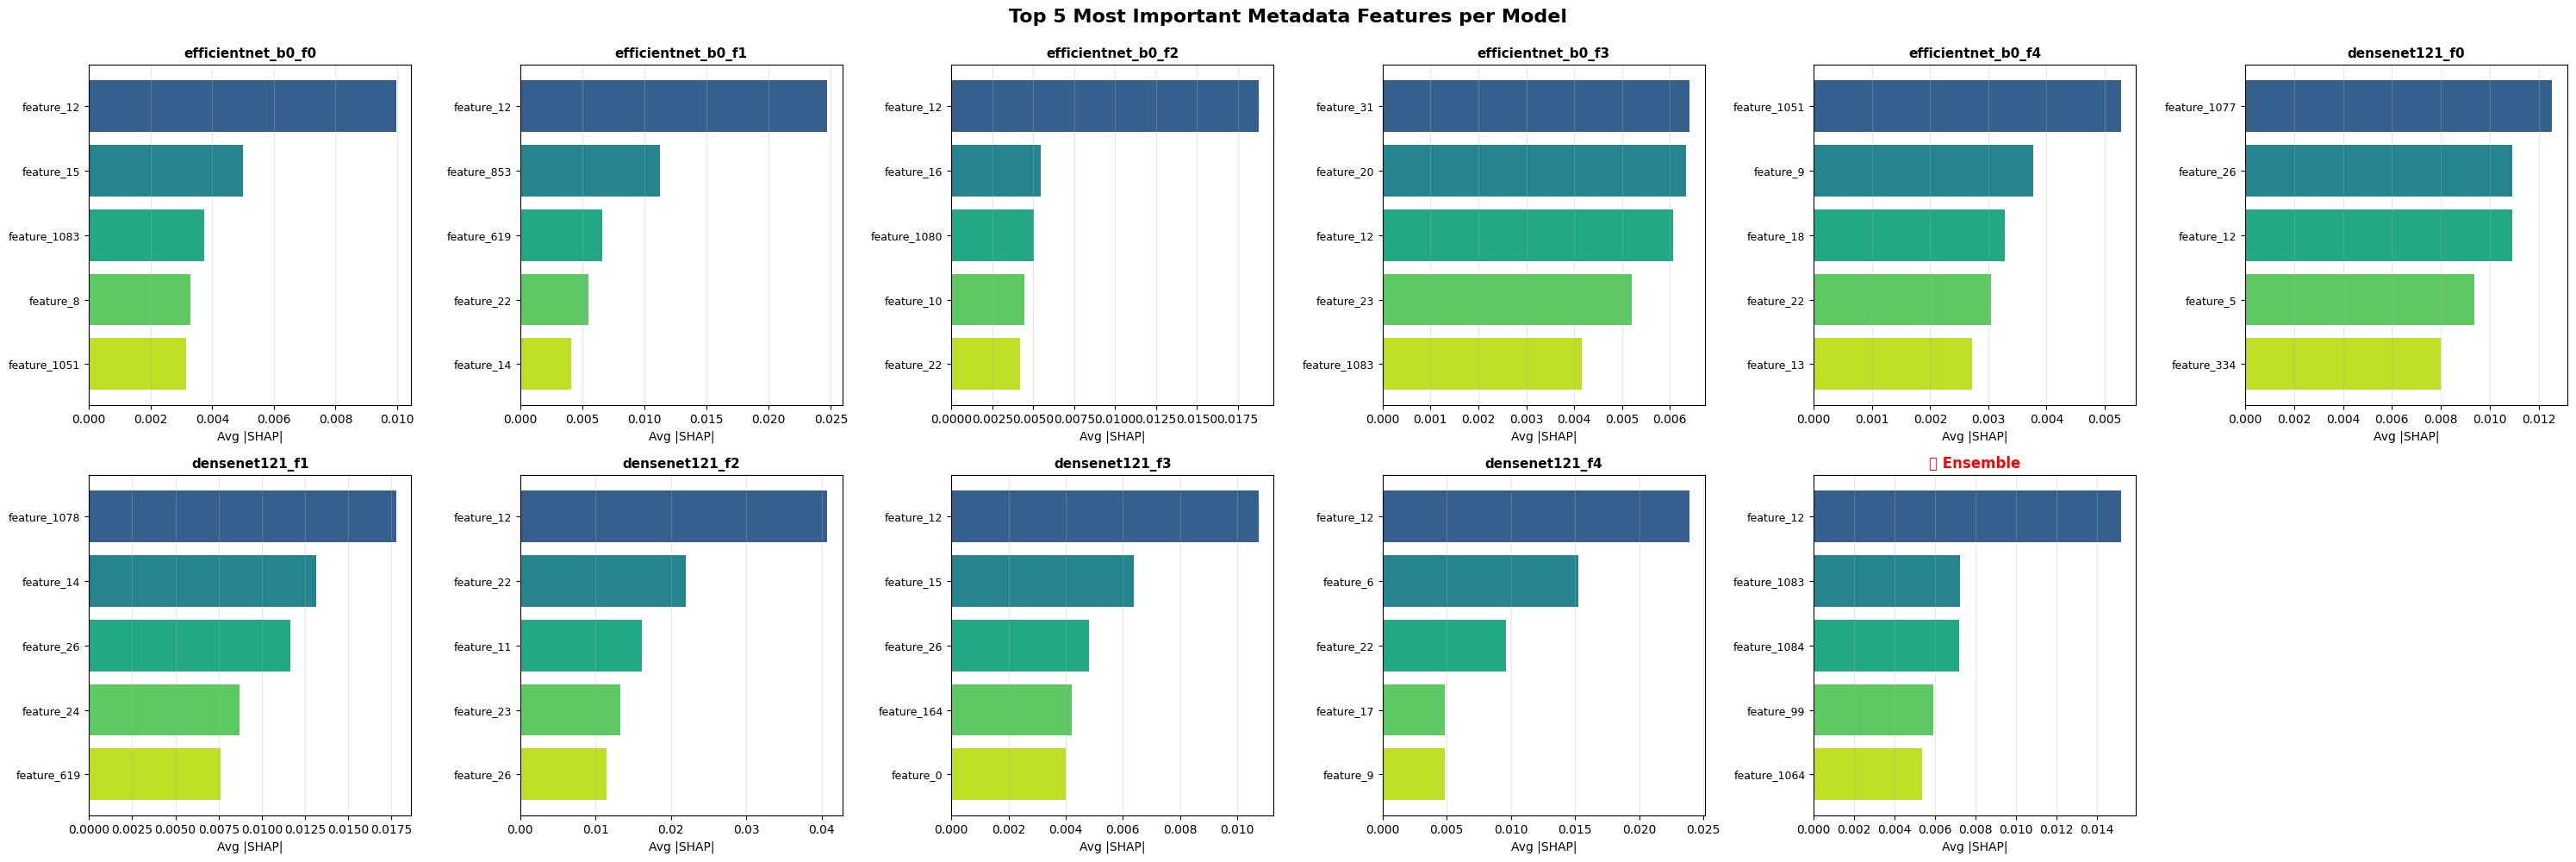


📊 Creating heatmap of feature importance across models...


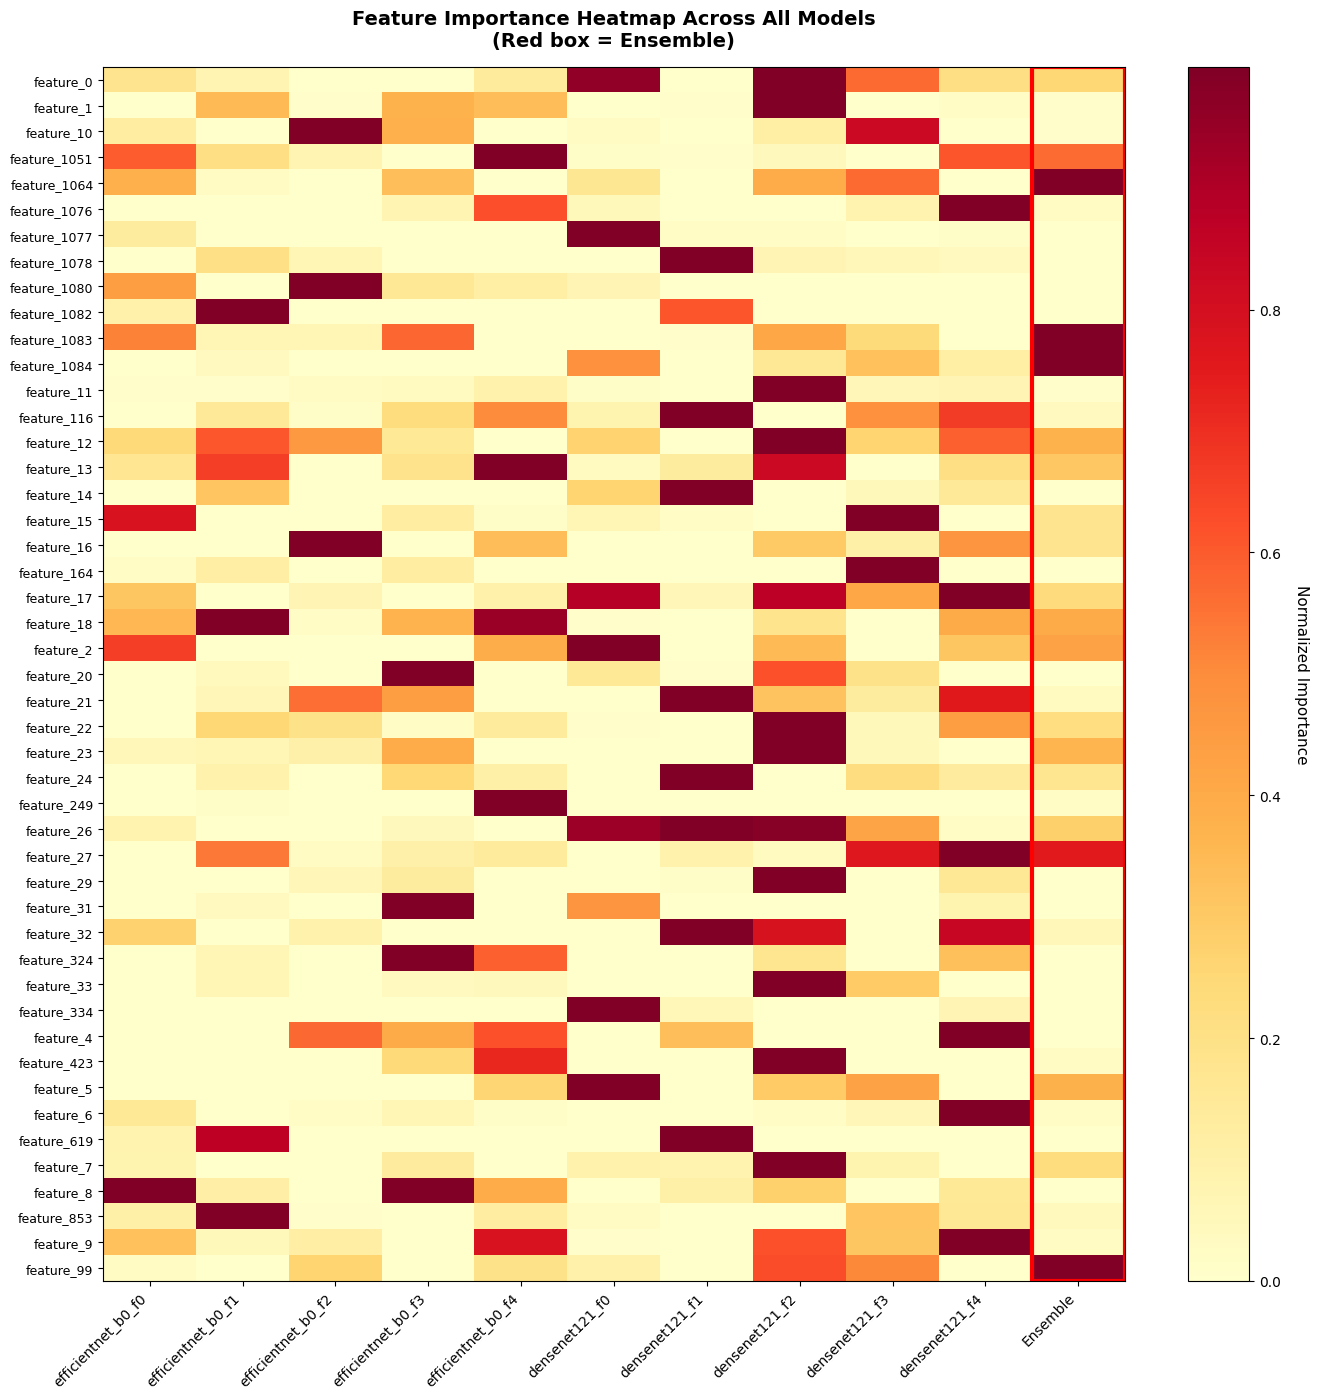


SUMMARY: FEATURE CONSISTENCY ACROSS MODELS

Most Consistently Important Features (appearing in multiple models' top 5):
--------------------------------------------------------------------------------
⭐ feature_12                               | Appears in 9/11 models
   Models: efficientnet_b0_f0, efficientnet_b0_f1, efficientnet_b0_f2...
   feature_22                               | Appears in 5/11 models
   Models: efficientnet_b0_f1, efficientnet_b0_f2, efficientnet_b0_f4...
   feature_26                               | Appears in 4/11 models
   Models: densenet121_f0, densenet121_f1, densenet121_f2...
⭐ feature_1083                             | Appears in 3/11 models
   Models: efficientnet_b0_f0, efficientnet_b0_f3, Ensemble
   feature_1051                             | Appears in 2/11 models
   Models: efficientnet_b0_f0, efficientnet_b0_f4
   feature_15                               | Appears in 2/11 models
   Models: efficientnet_b0_f0, densenet121_f3
   feature_14          

In [41]:
# Compare feature importance across all models + ensemble using SHAP
print("=" * 80)
print("COMPUTING SHAP VALUES FOR ALL MODELS")
print("=" * 80)

# Prepare smaller dataset for efficiency
n_background_multi = 15
n_explain_multi = 5

# Get validation metadata from earlier in the notebook
val_viz_metadata = metadata_processor.transform(val_df.head(100))
background_data_multi = val_viz_metadata[:n_background_multi]
explain_data_multi = val_viz_metadata[n_background_multi:n_background_multi+n_explain_multi]

# Dictionary to store SHAP values for each model
all_model_shap = {}

# 1. Compute SHAP for each individual model
for idx, (model, model_name) in enumerate(zip(loaded_models, loaded_model_names)):
    print(f"\n[{idx+1}/{len(loaded_models)}] Computing SHAP for {model_name}...")
    
    # Move model to CPU
    model.to('cpu')
    predictor_temp = MetadataOnlyPredictor(model, torch.device('cpu'))
    
    # Create SHAP explainer
    explainer_temp = shap.KernelExplainer(
        model=lambda x: predictor_temp.predict_proba(x)[:, 1],
        data=background_data_multi,
        link="identity"
    )
    
    # Compute SHAP values
    shap_values_temp = explainer_temp.shap_values(explain_data_multi, nsamples=50)
    
    # Store average absolute SHAP values
    all_model_shap[model_name] = np.abs(shap_values_temp).mean(axis=0)
    
    # Move model back to GPU
    model.to(config.device)
    
    print(f"  ✓ Complete")

# 2. Compute SHAP for ensemble (using SoftVotingEnsemble if available)
print(f"\n[{len(loaded_models)+1}/{len(loaded_models)+1}] Computing SHAP for Ensemble...")

# Create ensemble predictor
class EnsembleMetadataPredictor:
    """Wrapper for ensemble predictions using only metadata"""
    def __init__(self, models, weights, device, image_size=224):
        self.models = models
        self.weights = torch.tensor(weights, dtype=torch.float32).to(device)
        self.device = device
        self.dummy_image = torch.zeros(1, 3, image_size, image_size).to(device)
        
        for m in self.models:
            m.eval()
    
    def predict_proba(self, metadata_array):
        with torch.no_grad():
            metadata_tensor = torch.FloatTensor(metadata_array).to(self.device)
            batch_size = metadata_array.shape[0]
            images = self.dummy_image.expand(batch_size, -1, -1, -1)
            
            # Collect predictions from all models
            preds = []
            for m in self.models:
                logits = m(images, metadata_tensor).squeeze()
                if logits.dim() == 0:
                    logits = logits.unsqueeze(0)
                preds.append(logits.unsqueeze(1))
            
            preds = torch.cat(preds, dim=1)  # (batch, num_models)
            
            # Weighted average (or equal weights for median)
            final_logits = (preds * self.weights).sum(dim=1)
            probs_malignant = torch.sigmoid(final_logits).cpu().numpy()
            probs_benign = 1 - probs_malignant
            
            return np.column_stack([probs_benign, probs_malignant])

# Define ensemble weights (equal for median)
ensemble_weights_shap = np.ones(len(loaded_models)) / len(loaded_models)

# Move all models to CPU
for m in loaded_models:
    m.to('cpu')

ensemble_predictor = EnsembleMetadataPredictor(
    loaded_models, 
    ensemble_weights_shap, 
    torch.device('cpu')
)

# Create SHAP explainer for ensemble
explainer_ensemble = shap.KernelExplainer(
    model=lambda x: ensemble_predictor.predict_proba(x)[:, 1],
    data=background_data_multi,
    link="identity"
)

# Compute SHAP values for ensemble
shap_values_ensemble = explainer_ensemble.shap_values(explain_data_multi, nsamples=50)
all_model_shap['Ensemble'] = np.abs(shap_values_ensemble).mean(axis=0)

# Move models back to GPU
for m in loaded_models:
    m.to(config.device)

print(f"  ✓ Complete")

print("\n✅ SHAP computation complete for all models!")

# 3. Create comparison visualization - Top 5 features per model
print("\n" + "=" * 80)
print("TOP 5 FEATURES COMPARISON ACROSS MODELS")
print("=" * 80)

# Get top 5 features for each model
model_names_all = loaded_model_names + ['Ensemble']
top_k = 5

fig, axes = plt.subplots(2, 6, figsize=(30, 10))
axes = axes.flatten()

for idx, model_name in enumerate(model_names_all):
    if idx >= len(axes):
        break
        
    shap_vals = all_model_shap[model_name]
    
    # Get top 5 features
    top_indices = np.argsort(shap_vals)[-top_k:][::-1]
    top_features = [feature_names[i] for i in top_indices]
    top_values = shap_vals[top_indices]
    
    # Plot
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_k))
    axes[idx].barh(range(top_k), top_values, color=colors)
    axes[idx].set_yticks(range(top_k))
    axes[idx].set_yticklabels(top_features, fontsize=9)
    axes[idx].set_xlabel('Avg |SHAP|', fontsize=10)
    
    # Highlight ensemble
    if model_name == 'Ensemble':
        axes[idx].set_title(f'⭐ {model_name}', fontweight='bold', fontsize=12, color='red')
    else:
        axes[idx].set_title(model_name, fontweight='bold', fontsize=11)
    
    axes[idx].invert_yaxis()
    axes[idx].grid(axis='x', alpha=0.3)

# Hide any unused subplots
for idx in range(len(model_names_all), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Top 5 Most Important Metadata Features per Model', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# 4. Create heatmap showing feature importance across all models
print("\n📊 Creating heatmap of feature importance across models...")

# Select top N features overall (union of all models' top features)
all_top_features = set()
for model_name in model_names_all:
    shap_vals = all_model_shap[model_name]
    top_indices = np.argsort(shap_vals)[-10:]  # Top 10 from each
    all_top_features.update([feature_names[i] for i in top_indices])

all_top_features = sorted(list(all_top_features))
n_features_heatmap = len(all_top_features)

# Create matrix: rows = features, columns = models
importance_matrix = np.zeros((n_features_heatmap, len(model_names_all)))

for col_idx, model_name in enumerate(model_names_all):
    shap_vals = all_model_shap[model_name]
    for row_idx, feat_name in enumerate(all_top_features):
        feat_idx = feature_names.index(feat_name)
        importance_matrix[row_idx, col_idx] = shap_vals[feat_idx]

# Normalize each row for better visualization
importance_matrix_norm = importance_matrix / (importance_matrix.max(axis=1, keepdims=True) + 1e-8)

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, max(8, n_features_heatmap * 0.3)))
im = ax.imshow(importance_matrix_norm, cmap='YlOrRd', aspect='auto')

# Set ticks
ax.set_xticks(np.arange(len(model_names_all)))
ax.set_yticks(np.arange(n_features_heatmap))
ax.set_xticklabels(model_names_all, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(all_top_features, fontsize=9)

# Highlight ensemble column
ensemble_idx = model_names_all.index('Ensemble')
ax.add_patch(plt.Rectangle((ensemble_idx-0.5, -0.5), 1, n_features_heatmap,
                           fill=False, edgecolor='red', linewidth=3))

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Normalized Importance', rotation=270, labelpad=20, fontsize=11)

# Add title
ax.set_title('Feature Importance Heatmap Across All Models\n(Red box = Ensemble)', 
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# 5. Print summary statistics
print("\n" + "=" * 80)
print("SUMMARY: FEATURE CONSISTENCY ACROSS MODELS")
print("=" * 80)

# Find features that appear in top 5 of multiple models
feature_appearance_count = {}
for model_name in model_names_all:
    shap_vals = all_model_shap[model_name]
    top_indices = np.argsort(shap_vals)[-5:]
    for idx in top_indices:
        feat = feature_names[idx]
        if feat not in feature_appearance_count:
            feature_appearance_count[feat] = []
        feature_appearance_count[feat].append(model_name)

# Sort by frequency
feature_freq = [(feat, len(models)) for feat, models in feature_appearance_count.items()]
feature_freq.sort(key=lambda x: x[1], reverse=True)

print("\nMost Consistently Important Features (appearing in multiple models' top 5):")
print("-" * 80)
for feat, count in feature_freq[:15]:
    models_list = feature_appearance_count[feat]
    in_ensemble = '⭐' if 'Ensemble' in models_list else '  '
    print(f"{in_ensemble} {feat:40s} | Appears in {count}/{len(model_names_all)} models")
    print(f"   Models: {', '.join(models_list[:3])}{'...' if len(models_list) > 3 else ''}")

print("\n✅ Feature importance comparison across all models complete!")


In [43]:
# See raw metadata columns
print(f"Raw metadata columns: {len(train_df.columns)}")
print(train_df.columns.tolist())

# See processed features
processed_metadata = metadata_processor.transform(train_df)
print(f"Processed features: {processed_metadata.shape[1]}")

# See feature names (if available)
if hasattr(metadata_processor, 'feature_names'):
    print(f"First 10 features: {metadata_processor.feature_names[:1080]}")

Raw metadata columns: 55
['isic_id', 'target', 'patient_id', 'age_approx', 'sex', 'anatom_site_general', 'clin_size_long_diam_mm', 'image_type', 'tbp_tile_type', 'tbp_lv_A', 'tbp_lv_Aext', 'tbp_lv_B', 'tbp_lv_Bext', 'tbp_lv_C', 'tbp_lv_Cext', 'tbp_lv_H', 'tbp_lv_Hext', 'tbp_lv_L', 'tbp_lv_Lext', 'tbp_lv_areaMM2', 'tbp_lv_area_perim_ratio', 'tbp_lv_color_std_mean', 'tbp_lv_deltaA', 'tbp_lv_deltaB', 'tbp_lv_deltaL', 'tbp_lv_deltaLB', 'tbp_lv_deltaLBnorm', 'tbp_lv_eccentricity', 'tbp_lv_location', 'tbp_lv_location_simple', 'tbp_lv_minorAxisMM', 'tbp_lv_nevi_confidence', 'tbp_lv_norm_border', 'tbp_lv_norm_color', 'tbp_lv_perimeterMM', 'tbp_lv_radial_color_std_max', 'tbp_lv_stdL', 'tbp_lv_stdLExt', 'tbp_lv_symm_2axis', 'tbp_lv_symm_2axis_angle', 'tbp_lv_x', 'tbp_lv_y', 'tbp_lv_z', 'attribution', 'copyright_license', 'lesion_id', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4', 'iddx_5', 'mel_mitotic_index', 'mel_thick_mm', 'tbp_lv_dnn_lesion_confidence']
Processed features: 1087
Process